## Run these cells in order every session:
## Cell 1 → Load data
## Cell 2 → Clean data  
## Cell 3 → Feature engineering

In [84]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [85]:
# 2. Define your file name
# IMPORTANT: You must put the EXACT full file name inside these quotes!
TPA_Sea = 'TPA - Sea - Cleaned - All - Digi Challenge.xlsx'
TPA_UK = 'TPA UK - Cleaned - All - Digi Challenge.xlsx'


In [86]:
xl_uk=pd.ExcelFile("TPA UK - Cleaned - All - Digi Challenge.xlsx")
xl_sea=pd.ExcelFile("TPA - Sea - Cleaned - All - Digi Challenge.xlsx")

In [87]:
# 2. Print the exact names of the tabs in each file
print("Sea Tabs:", xl_sea.sheet_names)
print("UK Tabs:", xl_uk.sheet_names)

Sea Tabs: ['Data Dump - Cleaned', 'Fields Description', 'KPI formulas']
UK Tabs: ['Data Dump - Granular', 'Data Dump - SPF(ppg) level', 'Fields Description', 'KPI Formulas']


In [88]:
df_UK = pd.read_excel(
    'TPA UK - Cleaned - All - Digi Challenge.xlsx',
    sheet_name='Data Dump - Granular'
)

df_sea = pd.read_excel(
    'TPA - Sea - Cleaned - All - Digi Challenge.xlsx',
    sheet_name='Data Dump - Cleaned'
)


In [89]:
# 1. Let's see exactly how massive these files are (Rows, Columns)
print("Sea Data Shape:", df_sea.shape)
print("UK Data Shape:", df_UK.shape)

Sea Data Shape: (460869, 48)
UK Data Shape: (279007, 45)


In [90]:
# Step 1: Look inside the data
print("Shape:", df_UK.shape)
print("\nColumn names:")
print(df_UK.columns.tolist())
print("\nFirst 3 rows:")
df_UK.head(3)

Shape: (279007, 45)

Column names:
['Level8Code', 'Customer', 'PromoIDText', 'PromoFlag', 'TUEAN', 'WeekSkID', 'InStoreStartWeek', 'InStoreEndWeek', 'PromotionStatus', 'InstoreStartDate', 'InstoreEndDate', 'ShipmentStartDate', 'ShipmentEndDate', 'PromoFeature', 'PromoMechanic', 'PromoShopperMechanic', 'DivisionName_VG', 'CategoryName_VG', 'SegmentName_VG', 'FormName_VG', 'EBFName_VG', 'Brand_VG', 'SPF', 'SPFVName_VG', 'ListPrice', 'PlannedPromoSalesVolumeSellIn', 'PlannedNetPromoGSVSellIn', 'PlannedTTSOnSpend', 'PlannedNetPromoNIVSellIn', 'PlannedTTSOffSpend', 'PlannedNetPromoTOSellIn', 'PlannedNetPromoGrossProfitsSellIn', 'PlannedNetPromoCOGSSellIn', 'PlannedBaselineVolume', 'PlannedBaseGSVSellIn', 'PlannedBaseTTSOnSpend', 'PlannedBaseNIVSellIn', 'PlannedBaseTTSOffSpend', 'PlannedBaseTOSellIn', 'PlannedBaseGrossProfitsSellIn', 'PlannedBaseCOGSSellIn', 'PlannedEventSpend', 'ActualPromoSalesVolumeSellOut', 'ActualBaselineVolume', 'ActualBaselineValue']

First 3 rows:


,Level8Code,Customer,PromoIDText,PromoFlag,TUEAN,WeekSkID,InStoreStartWeek,InStoreEndWeek,PromotionStatus,InstoreStartDate,...,PlannedBaseTTSOnSpend,PlannedBaseNIVSellIn,PlannedBaseTTSOffSpend,PlannedBaseTOSellIn,PlannedBaseGrossProfitsSellIn,PlannedBaseCOGSSellIn,PlannedEventSpend,ActualPromoSalesVolumeSellOut,ActualBaselineVolume,ActualBaselineValue
0,350300,TESCO STORES LTD,P-00426559,TESCO STORES LTD-Multiple Products-Multi-Buy-W...,8712566924394,2023-39,"2,023.36","2,023.40",Executed,2023-09-06,...,48.53,185.84,1.92,183.92,120.71,63.21,193.94,492.00,171.38,214.22
1,350300,TESCO STORES LTD,P-00426559,TESCO STORES LTD-Multiple Products-Multi-Buy-W...,8712566924394,2023-38,"2,023.36","2,023.40",Executed,2023-09-06,...,65.02,248.99,2.57,246.42,157.42,89.00,206.06,391.00,171.38,214.22
2,350300,TESCO STORES LTD,P-00426559,TESCO STORES LTD-Multiple Products-Multi-Buy-W...,8712566924394,2023-36,"2,023.36","2,023.40",Executed,2023-09-06,...,63.52,243.24,2.51,240.73,153.79,86.94,206.06,276.03,122.41,153.02


In [91]:
TARGET = 'ActualPromoSalesVolumeSellOut'

print("=== TARGET VARIABLE ANALYSIS ===")
print(df_UK[TARGET].describe().round(2))
print(f"\nSkewness:    {df_UK[TARGET].skew():.2f}")
print(f"Zero values: {(df_UK[TARGET] == 0).sum():,}")
print(f"Negative:    {(df_UK[TARGET] < 0).sum():,}")

=== TARGET VARIABLE ANALYSIS ===
count   279,007.00
mean      3,419.46
std       9,665.42
min           0.00
25%           7.88
50%         859.00
75%       3,166.00
max     457,950.00
Name: ActualPromoSalesVolumeSellOut, dtype: float64

Skewness:    12.87
Zero values: 52,988
Negative:    0


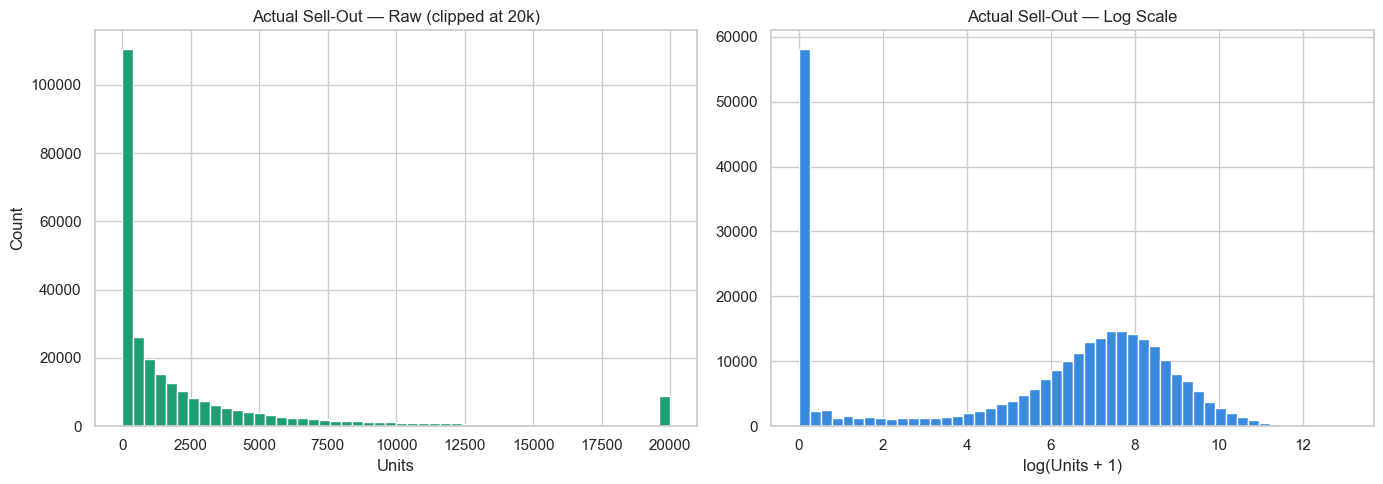

In [92]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw distribution
axes[0].hist(df_UK[TARGET].clip(upper=20000), 
             bins=50, color='#1D9E75', edgecolor='white')
axes[0].set_title('Actual Sell-Out — Raw (clipped at 20k)')
axes[0].set_xlabel('Units')
axes[0].set_ylabel('Count')

# Right: log distribution  
axes[1].hist(np.log1p(df_UK[TARGET]), 
             bins=50, color='#378ADD', edgecolor='white')
axes[1].set_title('Actual Sell-Out — Log Scale')
axes[1].set_xlabel('log(Units + 1)')

plt.tight_layout()
plt.show()

In [93]:
# How many rows do we keep vs remove?
print(f"Before filter: {len(df_UK):,}")

df_exec = df_UK[df_UK[TARGET] > 0].copy()

print(f"After filter:  {len(df_exec):,}")
print(f"Removed:       {len(df_UK) - len(df_exec):,} rows")
print(f"Remaining:     {len(df_exec)/len(df_UK)*100:.1f}% of data")

Before filter: 279,007
After filter:  226,019
Removed:       52,988 rows
Remaining:     81.0% of data


In [94]:
print(df_exec['PromotionStatus'].value_counts())

PromotionStatus
Executed    225861
InFlight       158
Name: count, dtype: int64


In [95]:
df_exec = df_exec[df_exec['PromotionStatus'] == 'Executed'].copy()

print(f"Final clean dataset: {len(df_exec):,} rows")

Final clean dataset: 225,861 rows


In [96]:
# Group columns by data type — much cleaner
print("=== NUMERIC COLUMNS ===")
print(df_exec.select_dtypes(include=['float64','int64']).columns.tolist())

print("\n=== STRING/CATEGORICAL COLUMNS ===")
print(df_exec.select_dtypes(include=['object','str']).columns.tolist())

print("\n=== DATETIME COLUMNS ===")
print(df_exec.select_dtypes(include=['datetime64']).columns.tolist())

print("\n=== SUMMARY ===")
print(df_exec.dtypes.value_counts())

=== NUMERIC COLUMNS ===
['Level8Code', 'TUEAN', 'InStoreStartWeek', 'InStoreEndWeek', 'ListPrice', 'PlannedPromoSalesVolumeSellIn', 'PlannedNetPromoGSVSellIn', 'PlannedTTSOnSpend', 'PlannedNetPromoNIVSellIn', 'PlannedTTSOffSpend', 'PlannedNetPromoTOSellIn', 'PlannedNetPromoGrossProfitsSellIn', 'PlannedNetPromoCOGSSellIn', 'PlannedBaselineVolume', 'PlannedBaseGSVSellIn', 'PlannedBaseTTSOnSpend', 'PlannedBaseNIVSellIn', 'PlannedBaseTTSOffSpend', 'PlannedBaseTOSellIn', 'PlannedBaseGrossProfitsSellIn', 'PlannedBaseCOGSSellIn', 'PlannedEventSpend', 'ActualPromoSalesVolumeSellOut', 'ActualBaselineVolume', 'ActualBaselineValue']

=== STRING/CATEGORICAL COLUMNS ===
['Customer', 'PromoIDText', 'PromoFlag', 'WeekSkID', 'PromotionStatus', 'PromoFeature', 'PromoMechanic', 'PromoShopperMechanic', 'DivisionName_VG', 'CategoryName_VG', 'SegmentName_VG', 'FormName_VG', 'EBFName_VG', 'Brand_VG', 'SPF', 'SPFVName_VG']

=== DATETIME COLUMNS ===
['InstoreStartDate', 'InstoreEndDate', 'ShipmentStartDate', 

In [97]:
print("=== CARDINALITY CHECK ===")
cat_cols = ['Customer', 'PromoFeature', 'PromoMechanic', 
            'PromoShopperMechanic', 'CategoryName_VG',
            'Brand_VG', 'SPFVName_VG', 'DivisionName_VG']

for col in cat_cols:
    if col in df_exec.columns:
        n = df_exec[col].nunique()
        print(f"{col:<30} {n:>6} unique values")

=== CARDINALITY CHECK ===
Customer                            7 unique values
PromoFeature                       16 unique values
PromoMechanic                       8 unique values
PromoShopperMechanic               88 unique values
CategoryName_VG                    16 unique values
Brand_VG                           56 unique values
SPFVName_VG                      1943 unique values
DivisionName_VG                     2 unique values


In [98]:
print("Customer values:")
print(df_exec['Customer'].unique())

print("\nPromoMechanic values:")
print(df_exec['PromoMechanic'].unique())

print("\nPromoFeature values:")
print(df_exec['PromoFeature'].unique())

Customer values:
<StringArray>
[                'TESCO STORES LTD',                 'BOOTS UK LIMITED',
                 'ASDA STORES LTD.',                     'WAITROSE LTD',
      'SAINSBURYS SUPERMARKETS LTD', 'WM MORRISON SUPERMARKETS LIMITED',
                   'T J MORRIS LTD']
Length: 7, dtype: str

PromoMechanic values:
<StringArray>
[            'Multi-Buy',                   'TPR',                  'EDLP',
                 'Other',             'Pipe Fill', 'Special Packs / Offer',
     'Shopper Marketing',               'Loyalty']
Length: 8, dtype: str

PromoFeature values:
<StringArray>
[             'Shelf',        'Gondola End', 'Free Standing Unit',
                  nan,        'Mid Gondola',             'Plinth',
     'None Specified',        'Shipper/OFD',         'Side Stack',
           'Hot Spot',              'Event',        'Pallet Drop',
        'Ladder Rack',             'Online',     'Store Entrance',
   'In queue fixture',      'Check out end']
Length: 17, d

In [99]:
print("Missing PromoFeature values:")
print(df_exec['PromoFeature'].isna().sum())

print("\nMissing values across ALL columns:")
print(df_exec.isnull().sum()[df_exec.isnull().sum() > 0])

Missing PromoFeature values:
13721

Missing values across ALL columns:
PromoFeature                         13721
PlannedPromoSalesVolumeSellIn         7041
PlannedNetPromoGSVSellIn              7041
PlannedTTSOnSpend                     7041
PlannedNetPromoNIVSellIn              7041
PlannedTTSOffSpend                    7041
PlannedNetPromoTOSellIn               7041
PlannedNetPromoGrossProfitsSellIn     7041
PlannedNetPromoCOGSSellIn             7041
PlannedEventSpend                     7041
dtype: int64


In [100]:
# Are the 7041 missing planned rows the same rows?
missing_planned = df_exec[
    df_exec['PlannedPromoSalesVolumeSellIn'].isna()
]

print(f"Rows with missing planned data: {len(missing_planned):,}")
print(f"\nDo they have actual sell-out?")
print(missing_planned[TARGET].describe().round(2))
print(f"\nPromotion status of missing rows:")
print(missing_planned['PromotionStatus'].value_counts())

Rows with missing planned data: 7,041

Do they have actual sell-out?
count     7,041.00
mean      4,748.34
std      12,299.52
min           0.00
25%         333.62
50%       1,397.86
75%       4,507.04
max     383,817.00
Name: ActualPromoSalesVolumeSellOut, dtype: float64

Promotion status of missing rows:
PromotionStatus
Executed    7041
Name: count, dtype: int64


In [101]:
# Fix 1: Fill missing PromoFeature with 'Unknown'
df_exec['PromoFeature'] = df_exec['PromoFeature'].fillna('Unknown')

# Fix 2: Drop rows with no planned data
df_exec = df_exec.dropna(
    subset=['PlannedPromoSalesVolumeSellIn']
).copy()

# Verify
print(f"Rows after cleaning: {len(df_exec):,}")
print(f"\nMissing values remaining:")
remaining = df_exec.isnull().sum()
remaining = remaining[remaining > 0]
print(remaining if len(remaining) > 0 else "✓ No missing values!")

Rows after cleaning: 218,820

Missing values remaining:
✓ No missing values!


In [102]:
Q1  = df_exec[TARGET].quantile(0.25)
Q3  = df_exec[TARGET].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_exec[
    (df_exec[TARGET] < lower) | 
    (df_exec[TARGET] > upper)
]

print(f"Q1:          {Q1:,.0f} units")
print(f"Q3:          {Q3:,.0f} units")
print(f"IQR:         {IQR:,.0f} units")
print(f"Upper bound: {upper:,.0f} units")
print(f"Lower bound: {lower:,.0f} units")
print(f"\nOutliers:    {len(outliers):,} rows ({len(outliers)/len(df_exec)*100:.1f}%)")
print(f"\nSample outlier rows:")
print(outliers[[TARGET, 'Customer', 'Brand_VG', 
                'PromoMechanic']].head(5))

Q1:          389 units
Q3:          4,077 units
IQR:         3,688 units
Upper bound: 9,609 units
Lower bound: -5,143 units

Outliers:    22,419 rows (10.2%)

Sample outlier rows:
      ActualPromoSalesVolumeSellOut          Customer Brand_VG PromoMechanic
26                        11,410.00  ASDA STORES LTD.      POT          EDLP
30                        11,222.50  ASDA STORES LTD.      POT          EDLP
34                         9,930.00  ASDA STORES LTD.      POT          EDLP
1020                      12,419.21  ASDA STORES LTD.     DOVE           TPR
1021                      13,212.00  ASDA STORES LTD.     DOVE           TPR


In [103]:
import numpy as np

# Log transform the target
df_exec['LogTarget'] = np.log1p(df_exec[TARGET])

print("Original target stats:")
print(f"  Mean:     {df_exec[TARGET].mean():>10,.1f}")
print(f"  Skewness: {df_exec[TARGET].skew():>10.2f}")

print("\nLog transformed target stats:")
print(f"  Mean:     {df_exec['LogTarget'].mean():>10.2f}")
print(f"  Skewness: {df_exec['LogTarget'].skew():>10.2f}")

Original target stats:
  Mean:        4,205.4
  Skewness:      11.89

Log transformed target stats:
  Mean:           6.80
  Skewness:      -1.17


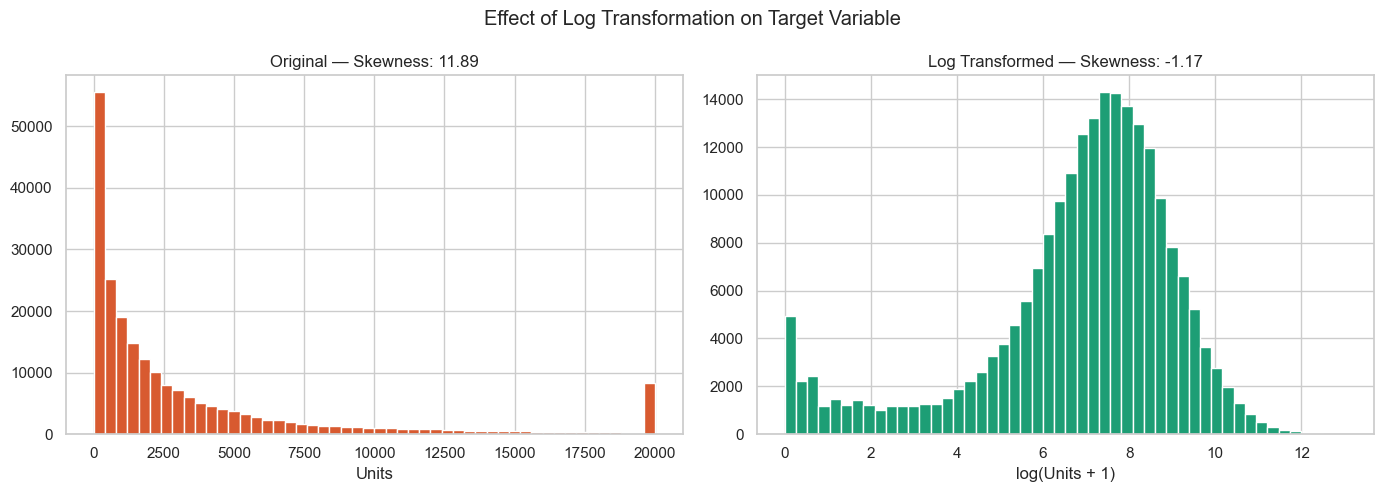

In [104]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_exec[TARGET].clip(upper=20000), 
             bins=50, color='#D85A30', edgecolor='white')
axes[0].set_title(f'Original — Skewness: {df_exec[TARGET].skew():.2f}')
axes[0].set_xlabel('Units')

axes[1].hist(df_exec['LogTarget'], 
             bins=50, color='#1D9E75', edgecolor='white')
axes[1].set_title(f'Log Transformed — Skewness: {df_exec["LogTarget"].skew():.2f}')
axes[1].set_xlabel('log(Units + 1)')

plt.suptitle('Effect of Log Transformation on Target Variable')
plt.tight_layout()
plt.show()

In [105]:
# Calculate planning accuracy
df_exec['PlanningGap'] = (
    df_exec['PlannedPromoSalesVolumeSellIn'] - df_exec[TARGET]
)

df_exec['MAPE'] = (
    abs(df_exec['PlanningGap']) / df_exec[TARGET] * 100
)

print("=== PLANNING ACCURACY ===")
print(f"Mean planning gap:  {df_exec['PlanningGap'].mean():>10,.0f} units")
print(f"Median gap:         {df_exec['PlanningGap'].median():>10,.0f} units")
print(f"Overall MAPE:       {df_exec['MAPE'].median():>10.1f}%")

print("\nMAPE by Customer:")
print(df_exec.groupby('Customer')['MAPE']
      .median().round(1)
      .sort_values(ascending=False))

=== PLANNING ACCURACY ===
Mean planning gap:         574 units
Median gap:                 21 units
Overall MAPE:             66.8%

MAPE by Customer:
Customer
T J MORRIS LTD                     100.00
ASDA STORES LTD.                    78.40
WAITROSE LTD                        75.20
BOOTS UK LIMITED                    67.80
WM MORRISON SUPERMARKETS LIMITED    64.70
SAINSBURYS SUPERMARKETS LTD         57.60
TESCO STORES LTD                    57.50
Name: MAPE, dtype: float64


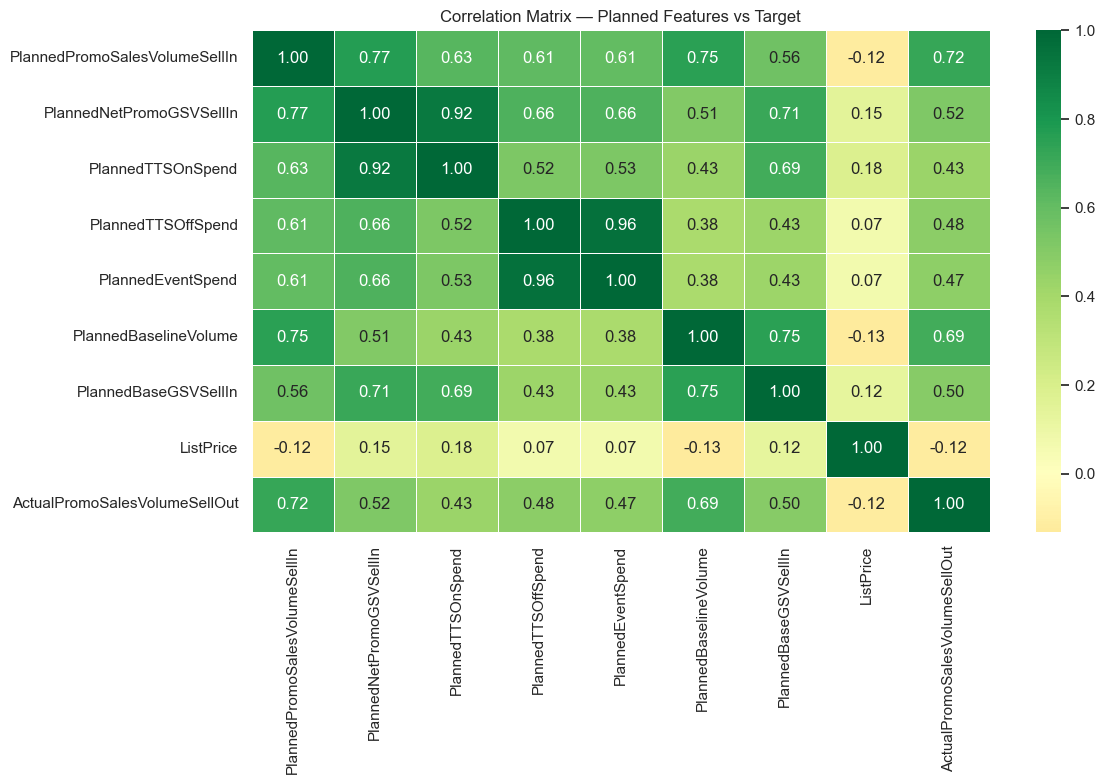


Correlation with target:
PlannedPromoSalesVolumeSellIn    0.72
PlannedBaselineVolume            0.69
PlannedNetPromoGSVSellIn         0.52
PlannedBaseGSVSellIn             0.50
PlannedTTSOffSpend               0.48
PlannedEventSpend                0.47
PlannedTTSOnSpend                0.43
ListPrice                       -0.12
Name: ActualPromoSalesVolumeSellOut, dtype: float64


In [106]:
import seaborn as sns
import matplotlib.pyplot as plt

# Only planned numeric columns — no leakage
planned_cols = [
    'PlannedPromoSalesVolumeSellIn',
    'PlannedNetPromoGSVSellIn',
    'PlannedTTSOnSpend',
    'PlannedTTSOffSpend',
    'PlannedEventSpend',
    'PlannedBaselineVolume',
    'PlannedBaseGSVSellIn',
    'ListPrice',
    TARGET
]

# Keep only columns that exist
planned_cols = [c for c in planned_cols if c in df_exec.columns]

# Correlation matrix
corr = df_exec[planned_cols].corr()

# Plot
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0,
            linewidths=0.5)
plt.title('Correlation Matrix — Planned Features vs Target')
plt.tight_layout()
plt.show()

# Most correlated with target
print("\nCorrelation with target:")
print(corr[TARGET].drop(TARGET)
      .sort_values(ascending=False).round(3))

In [107]:
# Planning accuracy ratio
df_UK['PlanningAccuracyRatio'] = (
    df_UK['ActualPromoSalesVolumeSellOut'] / df_UK['PlannedPromoSalesVolumeSellIn']
)

# Cap extreme outliers for analysis (not for features yet)
ratio = df_UK['PlanningAccuracyRatio']

print("=== Planning Accuracy Distribution ===")
print(ratio.describe(percentiles=[.05, .25, .5, .75, .95]))
print(f"\nMedian accuracy ratio : {ratio.median():.3f}")
print(f"% rows where actual > plan : {(ratio > 1).mean()*100:.1f}%")
print(f"% rows within 20% of plan  : {((ratio > 0.8) & (ratio < 1.2)).mean()*100:.1f}%")
print(f"% rows off by >50%         : {((ratio < 0.5) | (ratio > 1.5)).mean()*100:.1f}%")

=== Planning Accuracy Distribution ===
count   262,075.00
mean           inf
std            NaN
min           0.00
5%            0.00
25%           0.15
50%           0.77
75%           1.58
95%            NaN
max            inf
Name: PlanningAccuracyRatio, dtype: float64

Median accuracy ratio : 0.774
% rows where actual > plan : 38.3%
% rows within 20% of plan  : 14.2%
% rows off by >50%         : 60.6%


c:\Program Files\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a
c:\Program Files\Python313\Lib\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


In [108]:
# Check how many rows have zero planned volume
zero_plan = (df_UK['PlannedPromoSalesVolumeSellIn'] == 0).sum()
print(f"Rows with zero PlannedPromoSalesVolumeSellIn: {zero_plan}")

# Recompute ratio safely — exclude zero-plan rows from analysis
df_uk_valid = df_UK[df_UK['PlannedPromoSalesVolumeSellIn'] > 0].copy()

df_uk_valid['PlanningAccuracyRatio'] = (
    df_uk_valid['ActualPromoSalesVolumeSellOut'] 
    / df_uk_valid['PlannedPromoSalesVolumeSellIn']
)

ratio = df_uk_valid['PlanningAccuracyRatio']

print(f"\n=== Planning Accuracy (zero-plan rows excluded) ===")
print(ratio.describe(percentiles=[.05, .25, .5, .75, .95]))
print(f"\nMedian accuracy ratio : {ratio.median():.3f}")
print(f"% rows where actual > plan : {(ratio > 1).mean()*100:.1f}%")
print(f"% rows within 20% of plan  : {((ratio > 0.8) & (ratio < 1.2)).mean()*100:.1f}%")
print(f"% rows off by >50%         : {((ratio < 0.5) | (ratio > 1.5)).mean()*100:.1f}%")

Rows with zero PlannedPromoSalesVolumeSellIn: 38570

=== Planning Accuracy (zero-plan rows excluded) ===
count   233,218.00
mean          2.06
std          66.54
min           0.00
5%            0.00
25%           0.06
50%           0.65
75%           1.22
95%           3.18
max      10,285.65
Name: PlanningAccuracyRatio, dtype: float64

Median accuracy ratio : 0.647
% rows where actual > plan : 33.4%
% rows within 20% of plan  : 16.9%
% rows off by >50%         : 60.1%


In [109]:
# How many rows have extreme ratios?
print("Ratio > 10  :", (ratio > 10).sum())
print("Ratio > 5   :", (ratio > 5).sum())
print("Ratio > 2   :", (ratio > 2).sum())
print("Ratio = 0   :", (ratio == 0).sum())

# Look at the worst offenders
print("\n=== Top 10 extreme ratios ===")
print(df_uk_valid.nlargest(10, 'PlanningAccuracyRatio')[
    ['Customer', 'PromoMechanic', 'TUEAN',
     'PlannedPromoSalesVolumeSellIn',
     'ActualPromoSalesVolumeSellOut',
     'PlanningAccuracyRatio']
])

Ratio > 10  : 3704
Ratio > 5   : 6766
Ratio > 2   : 24025
Ratio = 0   : 43097

=== Top 10 extreme ratios ===
            Customer PromoMechanic          TUEAN  \
105370  WAITROSE LTD         Other  8710908458637   
105365  WAITROSE LTD         Other  8710908458637   
105366  WAITROSE LTD         Other  8710908458637   
105372  WAITROSE LTD         Other  8710908458637   
105364  WAITROSE LTD         Other  8710908458637   
105367  WAITROSE LTD         Other  8710908458637   
105374  WAITROSE LTD         Other  8710908458637   
105371  WAITROSE LTD         Other  8710908458637   
105373  WAITROSE LTD         Other  8710908458637   
105369  WAITROSE LTD         Other  8710908458637   

        PlannedPromoSalesVolumeSellIn  ActualPromoSalesVolumeSellOut  \
105370                           0.18                       1,894.00   
105365                           0.21                       2,114.00   
105366                           0.21                       2,105.00   
105372             

In [110]:
# Summarise the problem groups
print("=== Problem group sizes ===")
print(f"Zero actual (failed promos)  : {(ratio == 0).sum():,}")
print(f"Ratio > 10 (data entry errors): {(ratio > 10).sum():,}")
print(f"Ratio 2-10 (extreme but real?) : {((ratio > 2) & (ratio <= 10)).sum():,}")
print(f"Ratio 0.01-2 (usable range)   : {((ratio >= 0.01) & (ratio <= 2)).sum():,}")

# Cap the ratio at 99th percentile for the feature
cap_value = ratio.quantile(0.99)
print(f"\n99th percentile cap value: {cap_value:.3f}")

df_uk_valid['PlanningAccuracyRatioCapped'] = ratio.clip(upper=cap_value)

# For model training: flag but keep zero-actual rows
df_uk_valid['PromoFailed'] = (df_uk_valid['ActualPromoSalesVolumeSellOut'] == 0).astype(int)

print(f"\nFinal valid dataset shape: {df_uk_valid.shape}")
print(f"PromoFailed rows: {df_uk_valid['PromoFailed'].sum():,}")

=== Problem group sizes ===
Zero actual (failed promos)  : 43,097
Ratio > 10 (data entry errors): 3,704
Ratio 2-10 (extreme but real?) : 20,321
Ratio 0.01-2 (usable range)   : 155,637

99th percentile cap value: 16.915

Final valid dataset shape: (233218, 48)
PromoFailed rows: 43,097


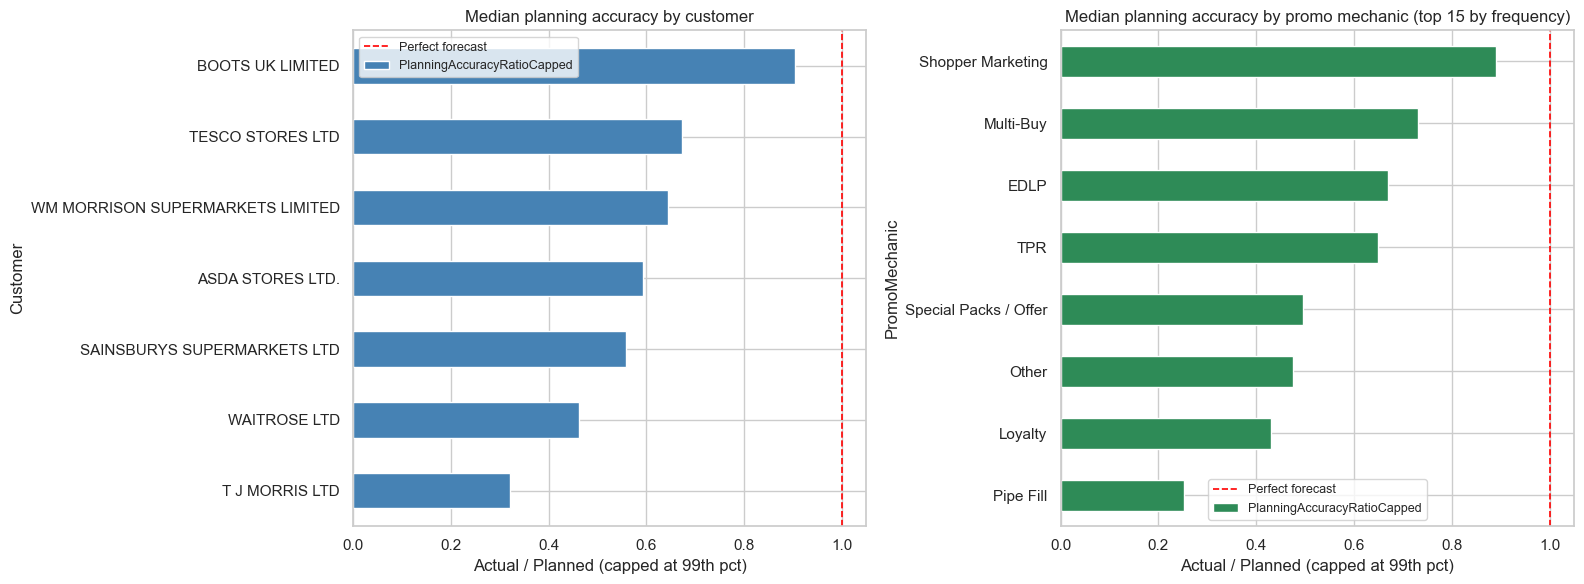

In [111]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# By Customer — use capped ratio
cust_acc = (df_uk_valid.groupby('Customer')['PlanningAccuracyRatioCapped']
                       .median()
                       .sort_values(ascending=True))

cust_acc.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].axvline(1.0, color='red', linestyle='--', linewidth=1.2, label='Perfect forecast')
axes[0].set_title('Median planning accuracy by customer')
axes[0].set_xlabel('Actual / Planned (capped at 99th pct)')
axes[0].legend(fontsize=9)

# By PromoMechanic — top 15 by frequency
top_mechs = df_uk_valid['PromoMechanic'].value_counts().head(15).index
mech_acc = (df_uk_valid[df_uk_valid['PromoMechanic'].isin(top_mechs)]
                .groupby('PromoMechanic')['PlanningAccuracyRatioCapped']
                .median()
                .sort_values(ascending=True))

mech_acc.plot(kind='barh', ax=axes[1], color='seagreen')
axes[1].axvline(1.0, color='red', linestyle='--', linewidth=1.2, label='Perfect forecast')
axes[1].set_title('Median planning accuracy by promo mechanic (top 15 by frequency)')
axes[1].set_xlabel('Actual / Planned (capped at 99th pct)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('planning_accuracy_by_customer_mechanic.png', dpi=150, bbox_inches='tight')
plt.show()

In [112]:
# Confirm Pipe Fill is not a real promo
pipe_fill = df_uk_valid[df_uk_valid['PromoMechanic'] == 'Pipe Fill']
print(f"Pipe Fill rows: {len(pipe_fill):,}")
print(f"Pipe Fill median actual volume  : {pipe_fill['ActualPromoSalesVolumeSellOut'].median():.1f}")
print(f"Pipe Fill median planned volume : {pipe_fill['PlannedPromoSalesVolumeSellIn'].median():.1f}")
print(f"Pipe Fill zero-actual rows      : {(pipe_fill['ActualPromoSalesVolumeSellOut'] == 0).sum():,}")

# Also check how many rows each mechanic has
print("\n=== Mechanic row counts ===")
print(df_uk_valid['PromoMechanic'].value_counts())

Pipe Fill rows: 1,644
Pipe Fill median actual volume  : 2006.7
Pipe Fill median planned volume : 9504.0
Pipe Fill zero-actual rows      : 182

=== Mechanic row counts ===
PromoMechanic
TPR                      149619
EDLP                      38030
Multi-Buy                 26674
Other                     15616
Pipe Fill                  1644
Loyalty                     736
Special Packs / Offer       465
Shopper Marketing           434
Name: count, dtype: int64


In [113]:
# Keep Pipe Fill but flag it
df_uk_valid['IsPipeFill'] = (df_uk_valid['PromoMechanic'] == 'Pipe Fill').astype(int)

# Summary of what we have going into feature engineering
print("=== Final dataset going into feature engineering ===")
print(f"Rows  : {len(df_uk_valid):,}")
print(f"Cols  : {df_uk_valid.shape[1]}")
print(f"\nPromoFailed (zero actual) : {df_uk_valid['PromoFailed'].sum():,}")
print(f"IsPipeFill                : {df_uk_valid['IsPipeFill'].sum():,}")
print(f"\nMechanic split:")
print(df_uk_valid['PromoMechanic'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

=== Final dataset going into feature engineering ===
Rows  : 233,218
Cols  : 49

PromoFailed (zero actual) : 43,097
IsPipeFill                : 1,644

Mechanic split:
PromoMechanic
TPR                      64.2%
EDLP                     16.3%
Multi-Buy                11.4%
Other                     6.7%
Pipe Fill                 0.7%
Loyalty                   0.3%
Special Packs / Offer     0.2%
Shopper Marketing         0.2%
Name: proportion, dtype: str


In [114]:
# ── Feature Engineering — Derived Numeric Features ──────────────────────────

df_uk_valid['PlannedIncrementalVolume'] = (
    df_uk_valid['PlannedPromoSalesVolumeSellIn'] - 
    df_uk_valid['PlannedBaselineVolume']
)

df_uk_valid['PlannedUpliftRate'] = (
    df_uk_valid['PlannedPromoSalesVolumeSellIn'] / 
    df_uk_valid['PlannedBaselineVolume'].replace(0, pd.NA)
).clip(upper=10)

df_uk_valid['PlannedTTSTotal'] = (
    df_uk_valid['PlannedTTSOnSpend'] + 
    df_uk_valid['PlannedTTSOffSpend'] + 
    df_uk_valid['PlannedEventSpend']
)

df_uk_valid['PlannedCostPerUnit'] = (
    df_uk_valid['PlannedTTSTotal'] / 
    df_uk_valid['PlannedPromoSalesVolumeSellIn'].replace(0, pd.NA)
)

df_uk_valid['PlannedROI_proxy'] = (
    df_uk_valid['PlannedNetPromoGrossProfitsSellIn'] / 
    df_uk_valid['PlannedTTSTotal'].replace(0, pd.NA)
).clip(lower=-10, upper=50)

df_uk_valid['PromoDurationWeeks'] = (
    df_uk_valid['InStoreEndWeek'] - df_uk_valid['InStoreStartWeek']
).clip(lower=0, upper=26)

print("=== New features summary ===")
new_feats = ['PlannedIncrementalVolume', 'PlannedUpliftRate', 
             'PlannedTTSTotal', 'PlannedCostPerUnit',
             'PlannedROI_proxy', 'PromoDurationWeeks']

print(df_uk_valid[new_feats].describe().round(3))
print(f"\nNull counts:")
print(df_uk_valid[new_feats].isnull().sum())

=== New features summary ===
       PlannedIncrementalVolume  PlannedTTSTotal  PlannedCostPerUnit  \
count                233,218.00       233,218.00          233,218.00   
mean                   2,285.76         9,047.43                2.67   
std                    7,913.77        18,011.52               12.21   
min                 -213,817.22       -17,097.97               -2.97   
25%                       31.24         1,493.65                1.20   
50%                      619.44         3,736.48                1.94   
75%                    2,274.00         9,212.08                2.90   
max                  453,814.86       709,791.71            1,532.53   

       PromoDurationWeeks  
count          233,218.00  
mean                 0.13  
std                  0.22  
min                  0.00  
25%                  0.03  
50%                  0.04  
75%                  0.08  
max                  1.01  

Null counts:
PlannedIncrementalVolume        0
PlannedUpliftRate     

In [115]:
# See the missing two separately
print(df_uk_valid[['PlannedUpliftRate', 'PlannedROI_proxy']].describe().round(3))
print("\nNull counts — all 6 features:")
print(df_uk_valid[new_feats].isnull().sum())

        PlannedUpliftRate  PlannedROI_proxy
count              221959            233205
unique             162446            168382
top                    10                50
freq                 9393                34

Null counts — all 6 features:
PlannedIncrementalVolume        0
PlannedUpliftRate           11259
PlannedTTSTotal                 0
PlannedCostPerUnit              0
PlannedROI_proxy               13
PromoDurationWeeks              0
dtype: int64


In [116]:
# Investigate negatives
print("=== Negative IncrementalVolume rows ===")
neg_vol = df_uk_valid[df_uk_valid['PlannedIncrementalVolume'] < 0]
print(f"Count: {len(neg_vol):,}")
print(neg_vol[['Customer', 'PromoMechanic', 
               'PlannedPromoSalesVolumeSellIn',
               'PlannedBaselineVolume',
               'PlannedIncrementalVolume']].head(5))

print("\n=== Negative TTS rows ===")
neg_tts = df_uk_valid[df_uk_valid['PlannedTTSTotal'] < 0]
print(f"Count: {len(neg_tts):,}")

print("\n=== PromoDuration investigation ===")
print("InStoreStartWeek sample:", df_uk_valid['InStoreStartWeek'].head(5).values)
print("InStoreEndWeek sample  :", df_uk_valid['InStoreEndWeek'].head(5).values)
print("Duration value counts  :")
print(df_uk_valid['PromoDurationWeeks'].value_counts().head(10))

=== Negative IncrementalVolume rows ===
Count: 51,454
             Customer PromoMechanic  PlannedPromoSalesVolumeSellIn  \
7    TESCO STORES LTD     Multi-Buy                       1,440.35   
8    TESCO STORES LTD     Multi-Buy                       1,440.35   
9    TESCO STORES LTD     Multi-Buy                       1,440.35   
170  BOOTS UK LIMITED     Multi-Buy                          72.00   
177  BOOTS UK LIMITED           TPR                          78.00   

     PlannedBaselineVolume  PlannedIncrementalVolume  
7                 2,341.88                   -901.53  
8                 2,341.88                   -901.53  
9                 2,341.88                   -901.53  
170                 120.00                    -48.00  
177                 155.09                    -77.09  

=== Negative TTS rows ===
Count: 12

=== PromoDuration investigation ===
InStoreStartWeek sample: [2023.36 2023.36 2023.36 2023.36 2023.36]
InStoreEndWeek sample  : [2023.4 2023.4 2023.4 2023.4 

In [117]:
import numpy as np

# ── Fix 1: PromoDuration — correct the YYYY.WW decimal format ───────────────
# Extract the week part: (2023.36 → 36), (2023.4 → 40)
# Multiply decimal by 100 to get week number, then subtract

start_week = (df_uk_valid['InStoreStartWeek'] % 1 * 100).round()
end_week   = (df_uk_valid['InStoreEndWeek'] % 1 * 100).round()

# Handle year rollover (e.g. start week 50, end week 04 next year)
df_uk_valid['PromoDurationWeeks'] = (end_week - start_week).clip(lower=0, upper=26)

print("=== Fixed PromoDurationWeeks ===")
print(df_uk_valid['PromoDurationWeeks'].value_counts().sort_index().head(10))

# ── Fix 2: Flag negative IncrementalVolume rows ──────────────────────────────
df_uk_valid['IsDefensivePromo'] = (
    df_uk_valid['PlannedIncrementalVolume'] < 0
).astype(int)

print(f"\nIsDefensivePromo rows : {df_uk_valid['IsDefensivePromo'].sum():,}")
print(f"% of dataset          : {df_uk_valid['IsDefensivePromo'].mean()*100:.1f}%")

# ── Fix 3: Fill nulls in ratio features ─────────────────────────────────────
# PlannedUpliftRate null = baseline was 0, so no uplift baseline exists → fill 1.0
df_uk_valid['PlannedUpliftRate'] = df_uk_valid['PlannedUpliftRate'].fillna(1.0)

# PlannedROI_proxy null = zero TTS spend → fill with median
roi_median = df_uk_valid['PlannedROI_proxy'].median()
df_uk_valid['PlannedROI_proxy'] = df_uk_valid['PlannedROI_proxy'].fillna(roi_median)

# Negative TTS (only 12 rows) → clip to 0
df_uk_valid['PlannedTTSTotal'] = df_uk_valid['PlannedTTSTotal'].clip(lower=0)
df_uk_valid['PlannedCostPerUnit'] = df_uk_valid['PlannedCostPerUnit'].clip(lower=0)

# ── Final check ──────────────────────────────────────────────────────────────
all_feats = ['PlannedIncrementalVolume', 'PlannedUpliftRate',
             'PlannedTTSTotal', 'PlannedCostPerUnit',
             'PlannedROI_proxy', 'PromoDurationWeeks', 'IsDefensivePromo']

print("\n=== Null counts after fixes ===")
print(df_uk_valid[all_feats].isnull().sum())

print("\n=== Updated dataset shape ===")
print(df_uk_valid.shape)

=== Fixed PromoDurationWeeks ===
PromoDurationWeeks
0.00    27536
1.00     2287
2.00     8946
3.00    65012
4.00    53713
5.00     3742
6.00    17930
7.00     2388
8.00    29495
9.00     3868
Name: count, dtype: int64

IsDefensivePromo rows : 51,454
% of dataset          : 22.1%

=== Null counts after fixes ===
PlannedIncrementalVolume    0
PlannedUpliftRate           0
PlannedTTSTotal             0
PlannedCostPerUnit          0
PlannedROI_proxy            0
PromoDurationWeeks          0
IsDefensivePromo            0
dtype: int64

=== Updated dataset shape ===
(233218, 56)


In [118]:
# Check all object columns remaining
cat_cols = df_uk_valid.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:")
for col in cat_cols:
    n = df_uk_valid[col].nunique()
    print(f"  {col:<35} {n:>6} unique values")

Categorical columns to encode:
  Customer                                 7 unique values
  PromoIDText                          11145 unique values
  PromoFlag                            10988 unique values
  WeekSkID                               129 unique values
  PromotionStatus                          2 unique values
  PromoFeature                            16 unique values


C:\Users\user\AppData\Local\Temp\ipykernel_26388\3753191570.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_uk_valid.select_dtypes(include='object').columns.tolist()


  PromoMechanic                            8 unique values
  PromoShopperMechanic                    91 unique values
  DivisionName_VG                          2 unique values
  CategoryName_VG                         16 unique values
  SegmentName_VG                         107 unique values
  FormName_VG                             93 unique values
  EBFName_VG                             348 unique values
  Brand_VG                                56 unique values
  SPF                                    660 unique values
  SPFVName_VG                           1811 unique values
  PlannedUpliftRate                   162446 unique values
  PlannedROI_proxy                    168382 unique values


In [119]:
from sklearn.preprocessing import LabelEncoder

# ── Fix 1: dtype bug on ratio features ──────────────────────────────────────
# When we used .replace(0, pd.NA) earlier, pandas silently converted these
# columns from float to 'object' (text) dtype. pd.to_numeric forces them
# back to numbers. errors='coerce' turns any unconvertible value into NaN,
# which we then fill with sensible defaults.

df_uk_valid['PlannedUpliftRate'] = pd.to_numeric(
    df_uk_valid['PlannedUpliftRate'], errors='coerce'
).fillna(1.0)  # 1.0 = no uplift (promo same as baseline)

df_uk_valid['PlannedROI_proxy'] = pd.to_numeric(
    df_uk_valid['PlannedROI_proxy'], errors='coerce'
).fillna(df_uk_valid['PlannedROI_proxy'].median())  # fill with typical value

# ── Fix 2: Drop ID columns ───────────────────────────────────────────────────
# PromoIDText and PromoFlag are identifier codes, not meaningful signals.
# If we kept them, the model would memorise specific promo IDs rather than
# learning patterns — like memorising exam answers instead of understanding.

df_uk_valid = df_uk_valid.drop(columns=['PromoIDText', 'PromoFlag'])
print("After dropping IDs. Shape:", df_uk_valid.shape)

# ── Fix 3: One-hot encode low cardinality columns ────────────────────────────
# ML models only understand numbers, not text like "Tesco" or "TPR".
# One-hot encoding converts each category into a separate 0/1 column.
# Example: PromoMechanic = ['TPR','EDLP','Multi-Buy'] becomes:
#   PromoMechanic_TPR=1, PromoMechanic_EDLP=0, PromoMechanic_Multi-Buy=0
# We only do this for columns with ≤16 unique values — otherwise we'd
# create hundreds of columns which slows training and causes overfitting.

ohe_cols = ['Customer',           # 7 unique
            'PromotionStatus',    # 2 unique  
            'DivisionName_VG',    # 2 unique
            'PromoMechanic',      # 8 unique  ← key business variable
            'PromoFeature',       # 16 unique
            'CategoryName_VG']    # 16 unique

df_uk_valid = pd.get_dummies(df_uk_valid, columns=ohe_cols, dtype=int)
print("After one-hot encoding. Shape:", df_uk_valid.shape)

# ── Fix 4: Label encode high cardinality columns ─────────────────────────────
# For columns with many unique values (50–1800), one-hot would create too
# many columns. Instead label encoding assigns each category a number:
# e.g. Brand_VG: ['Dove'→0, 'Persil'→1, 'Sure'→2, ...]
# Tree-based models (XGBoost, Random Forest) handle this well.
# Linear models technically shouldn't use label encoding but we'll apply
# PCA/scaling on top which mitigates this.

le_cols = ['Brand_VG',              # 56 unique
           'WeekSkID',              # 129 unique — time dimension
           'PromoShopperMechanic',  # 91 unique
           'SegmentName_VG',        # 107 unique
           'FormName_VG',           # 93 unique
           'EBFName_VG',            # 348 unique
           'SPF',                   # 660 unique
           'SPFVName_VG']           # 1811 unique

le = LabelEncoder()
for col in le_cols:
    # astype(str) first ensures any NaN values become the string "nan"
    # rather than crashing the encoder
    df_uk_valid[col] = le.fit_transform(df_uk_valid[col].astype(str))
    print(f"  Encoded {col}")

# ── Final validation ─────────────────────────────────────────────────────────
# After encoding, NO object (text) columns should remain.
# If any do, the model training step will crash.

remaining_obj = df_uk_valid.select_dtypes(include='object').columns.tolist()
print(f"\nRemaining object columns: {remaining_obj}")  # should be empty []
print(f"\nFinal dtypes summary:")
print(df_uk_valid.dtypes.value_counts())
print(f"\nFinal shape: {df_uk_valid.shape}")

After dropping IDs. Shape: (233218, 54)
After one-hot encoding. Shape: (233218, 99)
  Encoded Brand_VG
  Encoded WeekSkID
  Encoded PromoShopperMechanic
  Encoded SegmentName_VG
  Encoded FormName_VG
  Encoded EBFName_VG
  Encoded SPF
  Encoded SPFVName_VG

Remaining object columns: []

Final dtypes summary:
int64             64
float64           31
datetime64[us]     4
Name: count, dtype: int64

Final shape: (233218, 99)


In [120]:
# ── Handle datetime columns ──────────────────────────────────────────────────
# First let's see which 4 they are
date_cols = df_uk_valid.select_dtypes(include='datetime64').columns.tolist()
print("Datetime columns:", date_cols)

# Extract month and week-of-year from each date — these carry seasonal signal
# e.g. Christmas promos in week 48-52 behave very differently to summer promos
for col in date_cols:
    df_uk_valid[col + '_Month'] = df_uk_valid[col].dt.month      # 1-12
    df_uk_valid[col + '_Week']  = df_uk_valid[col].dt.isocalendar().week.astype(int)  # 1-52

# Drop the original datetime columns — models can't use them raw
df_uk_valid = df_uk_valid.drop(columns=date_cols)

print(f"\nExtracted month + week from {len(date_cols)} date columns")
print(f"Shape after date extraction: {df_uk_valid.shape}")

# ── Final dtype check — everything must be numeric now ───────────────────────
remaining_non_numeric = df_uk_valid.select_dtypes(
    exclude=['int64','float64','int32','float32']
).columns.tolist()

print(f"\nRemaining non-numeric columns: {remaining_non_numeric}")  # must be []
print(f"\nNull values remaining in dataset: {df_uk_valid.isnull().sum().sum()}")

Datetime columns: ['InstoreStartDate', 'InstoreEndDate', 'ShipmentStartDate', 'ShipmentEndDate']

Extracted month + week from 4 date columns
Shape after date extraction: (233218, 103)

Remaining non-numeric columns: []

Null values remaining in dataset: 0


In [121]:
from sklearn.model_selection import train_test_split

# ── Define target variable ───────────────────────────────────────────────────
# This is what we're predicting — actual sell-out volume
# We use the log-transformed version to handle the heavy right skew
# we identified in EDA. Log transform makes the target more normally
# distributed which helps all models learn better.

TARGET = 'ActualPromoSalesVolumeSellOut'

# ── Remove columns that must not be used as features ────────────────────────
# These are either:
# (a) Post-execution actuals — data leakage, not available at prediction time
# (b) Direct derivations of the target
# (c) Row identifiers

leakage_cols = [
    TARGET,                      # the target itself
    'ActualBaselineVolume',       # actual post-execution data
    'ActualBaselineValue',        # actual post-execution data
    'PromoFailed',                # derived from actual (ActualSellOut == 0)
    'PlanningAccuracyRatio',      # derived from actual / planned
    'PlanningAccuracyRatioCapped' # same
]

# Only drop columns that actually exist in the dataframe
leakage_cols = [c for c in leakage_cols if c in df_uk_valid.columns]
print("Dropping leakage columns:", leakage_cols)

# ── Define feature matrix X and target vector y ──────────────────────────────
# X = everything except the target and leakage columns
# y = the target we want to predict

X = df_uk_valid.drop(columns=leakage_cols)
y = df_uk_valid[TARGET]

print(f"\nFeature matrix X shape : {X.shape}")
print(f"Target vector y shape  : {y.shape}")
print(f"Target min / max       : {y.min():.1f} / {y.max():.1f}")
print(f"Target median          : {y.median():.1f}")

# ── Log-transform the target ─────────────────────────────────────────────────
# np.log1p = log(1 + x), which handles zeros safely (log(0) = -inf)
# We'll reverse this with np.expm1 when we evaluate predictions

import numpy as np
y_log = np.log1p(y)
print(f"\nLog-transformed target — min: {y_log.min():.3f}  "
      f"max: {y_log.max():.3f}  median: {y_log.median():.3f}")

# ── Train / test split ───────────────────────────────────────────────────────
# IMPORTANT: we use shuffle=False to respect time order.
# Random splitting would leak future data into training — a model trained
# on week 52 data predicting week 10 is unrealistic in production.
# Instead we train on the first 80% of rows (earlier weeks) and test on
# the last 20% (later weeks) — this mimics real-world deployment.

X_train, X_test, y_train, y_test = train_test_split(
    X, y_log,
    test_size=0.2,
    shuffle=False    # respect chronological order
)

print(f"\n=== Train / test split ===")
print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_test  : {y_test.shape}")
print(f"\nTrain target median : {y_train.median():.3f}")
print(f"Test target median  : {y_test.median():.3f}")

Dropping leakage columns: ['ActualPromoSalesVolumeSellOut', 'ActualBaselineVolume', 'ActualBaselineValue', 'PromoFailed', 'PlanningAccuracyRatio', 'PlanningAccuracyRatioCapped']

Feature matrix X shape : (233218, 97)
Target vector y shape  : (233218,)
Target min / max       : 0.0 / 457950.0
Target median          : 1034.0

Log-transformed target — min: 0.000  max: 13.035  median: 6.942

=== Train / test split ===
X_train : (186574, 97)
X_test  : (46644, 97)
y_train : (186574,)
y_test  : (46644,)

Train target median : 6.940
Test target median  : 6.952


In [122]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# ── Scale features ───────────────────────────────────────────────────────────
# StandardScaler transforms each column to mean=0, std=1.
# CRITICAL: fit ONLY on training data, then apply to both.
# If we fit on the full dataset, test data "leaks" its statistics
# into the scaler — another form of data leakage.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform train
X_test_scaled  = scaler.transform(X_test)         # transform only on test

print("Scaling complete.")
print(f"X_train_scaled mean (should be ~0): {X_train_scaled.mean():.4f}")
print(f"X_train_scaled std  (should be ~1): {X_train_scaled.std():.4f}")

# ── Helper function — evaluate any model consistently ───────────────────────
# We'll reuse this for every model so results are always comparable.
# RMSE = root mean squared error (same units as log-target)
# MAE  = mean absolute error (more robust to outliers than RMSE)
# R²   = proportion of variance explained (1.0 = perfect, 0.0 = useless)

def evaluate_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  R²   : {r2:.4f}")
    return {'Model': name, 'RMSE': round(rmse,4),
            'MAE': round(mae,4), 'R2': round(r2,4)}

results = []   # we'll collect all model results here for comparison later

# ── Model 1: Linear Regression ───────────────────────────────────────────────
# The simplest possible model. Fits a straight line through the data.
# This is our absolute baseline — every subsequent model must beat it.
# Uses scaled features because coefficients are sensitive to feature scale.

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
results.append(evaluate_model("Linear Regression", y_test, y_pred_lr))

# ── Model 2: Ridge Regression ────────────────────────────────────────────────
# Linear regression + L2 penalty that shrinks large coefficients.
# Better than plain linear when features are correlated (ours are — 0.92).
# alpha controls penalty strength — 1.0 is a neutral starting point.

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)
results.append(evaluate_model("Ridge Regression (alpha=1.0)", y_test, y_pred_ridge))

# ── Model 3: Lasso Regression ────────────────────────────────────────────────
# Linear regression + L1 penalty that can zero out weak features entirely.
# Effectively performs automatic feature selection.
# Watch how many features it keeps vs zeros out.

lasso = Lasso(alpha=0.01, max_iter=5000)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)
results.append(evaluate_model("Lasso Regression (alpha=0.01)", y_test, y_pred_lasso))

n_zero = (lasso.coef_ == 0).sum()
print(f"\n  Lasso zeroed out {n_zero} of {len(lasso.coef_)} features")

# ── Summary table so far ─────────────────────────────────────────────────────
import pandas as pd
results_df = pd.DataFrame(results).sort_values('RMSE')
print("\n=== Linear Models Comparison ===")
print(results_df.to_string(index=False))

Scaling complete.
X_train_scaled mean (should be ~0): -0.0000
X_train_scaled std  (should be ~1): 1.0000

  Linear Regression
  RMSE : 3.0663
  MAE  : 2.4664
  R²   : 0.1508

  Ridge Regression (alpha=1.0)
  RMSE : 3.0662
  MAE  : 2.4664
  R²   : 0.1508

  Lasso Regression (alpha=0.01)
  RMSE : 3.0799
  MAE  : 2.4940
  R²   : 0.1432

  Lasso zeroed out 29 of 97 features

=== Linear Models Comparison ===
                        Model  RMSE  MAE   R2
 Ridge Regression (alpha=1.0)  3.07 2.47 0.15
            Linear Regression  3.07 2.47 0.15
Lasso Regression (alpha=0.01)  3.08 2.49 0.14


In [123]:
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

# ── Model 4: Random Forest ───────────────────────────────────────────────────
# Builds 100 decision trees on random subsets of data and averages them.
# Does NOT need scaled features — trees split on raw values, not distances.
# n_jobs=-1 uses all CPU cores to train in parallel — faster on 186K rows.
# We use X_train (unscaled) here, not X_train_scaled.

print("Training Random Forest — this may take 2-3 minutes...")
rf = RandomForestRegressor(
    n_estimators=100,   # number of trees
    max_depth=15,       # how deep each tree can grow — controls overfitting
    min_samples_leaf=5, # each leaf must have at least 5 rows — prevents memorising noise
    n_jobs=-1,          # use all CPU cores
    random_state=42     # reproducibility
)
rf.fit(X_train, y_train)   # unscaled features
y_pred_rf = rf.predict(X_test)
results.append(evaluate_model("Random Forest (100 trees)", y_test, y_pred_rf))

# ── Model 5: XGBoost ─────────────────────────────────────────────────────────
# Builds trees sequentially — each tree corrects errors of the previous one.
# Industry standard for tabular data. Also uses unscaled features.
# eval_metric suppresses verbose output during training.

print("\nTraining XGBoost...")
xgb_model = xgb.XGBRegressor(
    n_estimators=300,     # number of boosting rounds
    learning_rate=0.05,   # how much each tree contributes — lower = more robust
    max_depth=6,          # tree depth
    subsample=0.8,        # use 80% of rows per tree — reduces overfitting
    colsample_bytree=0.8, # use 80% of features per tree
    n_jobs=-1,
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
results.append(evaluate_model("XGBoost", y_test, y_pred_xgb))

# ── Full comparison table — all 5 models ────────────────────────────────────
results_df = pd.DataFrame(results).sort_values('RMSE')
print("\n=== All Models Comparison ===")
print(results_df.to_string(index=False))
print("\nBest model so far:", results_df.iloc[0]['Model'])
print("Best RMSE        :", results_df.iloc[0]['RMSE'])
print("Best R²          :", results_df.iloc[0]['R2'])

Training Random Forest — this may take 2-3 minutes...

  Random Forest (100 trees)
  RMSE : 2.7370
  MAE  : 2.1493
  R²   : 0.3234

Training XGBoost...

  XGBoost
  RMSE : 2.1246
  MAE  : 1.6293
  R²   : 0.5923

=== All Models Comparison ===
                        Model  RMSE  MAE   R2
                      XGBoost  2.12 1.63 0.59
    Random Forest (100 trees)  2.74 2.15 0.32
 Ridge Regression (alpha=1.0)  3.07 2.47 0.15
            Linear Regression  3.07 2.47 0.15
Lasso Regression (alpha=0.01)  3.08 2.49 0.14

Best model so far: XGBoost
Best RMSE        : 2.1246
Best R²          : 0.5923


In [124]:
import lightgbm as lgb

# ── Model 6: LightGBM ────────────────────────────────────────────────────────
# Very similar to XGBoost but grows trees leaf-wise instead of level-wise.
# Leaf-wise growth: always splits the leaf that reduces loss the most.
# Level-wise growth (XGBoost): splits all leaves at the same depth evenly.
# Leaf-wise is more aggressive — often better accuracy, slightly more
# prone to overfitting, which we control with min_child_samples.
# On large datasets (our 186K rows) LightGBM is typically faster than XGBoost.

print("Training LightGBM...")
lgb_model = lgb.LGBMRegressor(
    n_estimators=300,       # same as XGBoost for fair comparison
    learning_rate=0.05,     # same as XGBoost
    max_depth=6,            # same as XGBoost
    subsample=0.8,          # use 80% of rows per tree
    colsample_bytree=0.8,   # use 80% of features per tree
    min_child_samples=20,   # minimum rows per leaf — controls overfitting
    n_jobs=-1,
    random_state=42,
    verbose=-1              # suppress training output
)
lgb_model.fit(X_train, y_train)
y_pred_lgb = lgb_model.predict(X_test)
results.append(evaluate_model("LightGBM", y_test, y_pred_lgb))

# ── Final comparison table — all 6 models ───────────────────────────────────
results_df = pd.DataFrame(results).sort_values('RMSE')
print("\n=== Final Model Comparison ===")
print(results_df.to_string(index=False))
print(f"\nWinner : {results_df.iloc[0]['Model']}")
print(f"RMSE   : {results_df.iloc[0]['RMSE']}")
print(f"R²     : {results_df.iloc[0]['R2']}")

Training LightGBM...

  LightGBM
  RMSE : 2.1582
  MAE  : 1.6593
  R²   : 0.5793

=== Final Model Comparison ===
                        Model  RMSE  MAE   R2
                      XGBoost  2.12 1.63 0.59
                     LightGBM  2.16 1.66 0.58
    Random Forest (100 trees)  2.74 2.15 0.32
 Ridge Regression (alpha=1.0)  3.07 2.47 0.15
            Linear Regression  3.07 2.47 0.15
Lasso Regression (alpha=0.01)  3.08 2.49 0.14

Winner : XGBoost
RMSE   : 2.1246
R²     : 0.5923


In [126]:
# ── Faster tuning — reduce data size for search, then train full model ───────
# Sample 50K rows for the search — fast but representative
# Then retrain the winner on the full 186K training set

import numpy as np
from sklearn.model_selection import RandomizedSearchCV

# Use only 50K rows for the hyperparameter search
sample_idx = np.random.RandomState(42).choice(len(X_train), size=50000, replace=False)
X_sample = X_train.iloc[sample_idx]
y_sample = y_train.iloc[sample_idx]

param_grid = {
    'n_estimators':     [200, 300, 500],
    'learning_rate':    [0.01, 0.05, 0.1],
    'max_depth':        [4, 6, 8],
    'subsample':        [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

search = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=42, verbosity=0, n_jobs=-1),
    param_distributions=param_grid,
    n_iter=20,          # reduced from 30 to 20
    cv=3,               # reduced from 5 to 3 folds
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Running tuning on 50K sample — should take 3-5 minutes...")
search.fit(X_sample, y_sample)

print(f"\nBest parameters:")
for param, value in search.best_params_.items():
    print(f"  {param:<25} {value}")
print(f"\nBest CV RMSE (on sample): {-search.best_score_:.4f}")

# ── Retrain best params on FULL training set ─────────────────────────────────
# The search found the best settings on a sample.
# Now we train a final model using those settings on all 186K rows
# to get maximum predictive power.

best_params = search.best_params_
xgb_tuned = xgb.XGBRegressor(
    **best_params,
    random_state=42,
    verbosity=0,
    n_jobs=-1
)

print("\nRetraining best model on full 186K training set...")
xgb_tuned.fit(X_train, y_train)

y_pred_tuned = xgb_tuned.predict(X_test)
results.append(evaluate_model("XGBoost (tuned)", y_test, y_pred_tuned))

results_df = pd.DataFrame(results).sort_values('RMSE')
print("\n=== Updated Model Comparison ===")
print(results_df.to_string(index=False))

Running tuning on 50K sample — should take 3-5 minutes...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best parameters:
  subsample                 0.9
  n_estimators              500
  max_depth                 8
  learning_rate             0.1
  colsample_bytree          0.8

Best CV RMSE (on sample): 1.7383

Retraining best model on full 186K training set...

  XGBoost (tuned)
  RMSE : 1.4596
  MAE  : 0.9788
  R²   : 0.8076

=== Updated Model Comparison ===
                        Model  RMSE  MAE   R2
              XGBoost (tuned)  1.46 0.98 0.81
                      XGBoost  2.12 1.63 0.59
                     LightGBM  2.16 1.66 0.58
    Random Forest (100 trees)  2.74 2.15 0.32
 Ridge Regression (alpha=1.0)  3.07 2.47 0.15
            Linear Regression  3.07 2.47 0.15
Lasso Regression (alpha=0.01)  3.08 2.49 0.14


=== Overfitting Check ===
                         RMSE       R²
Train                  0.9464   0.9204
Test                   1.4596   0.8076
Gap (train-test)      -0.5133   0.1128

MODERATE: Some overfitting — acceptable for this dataset


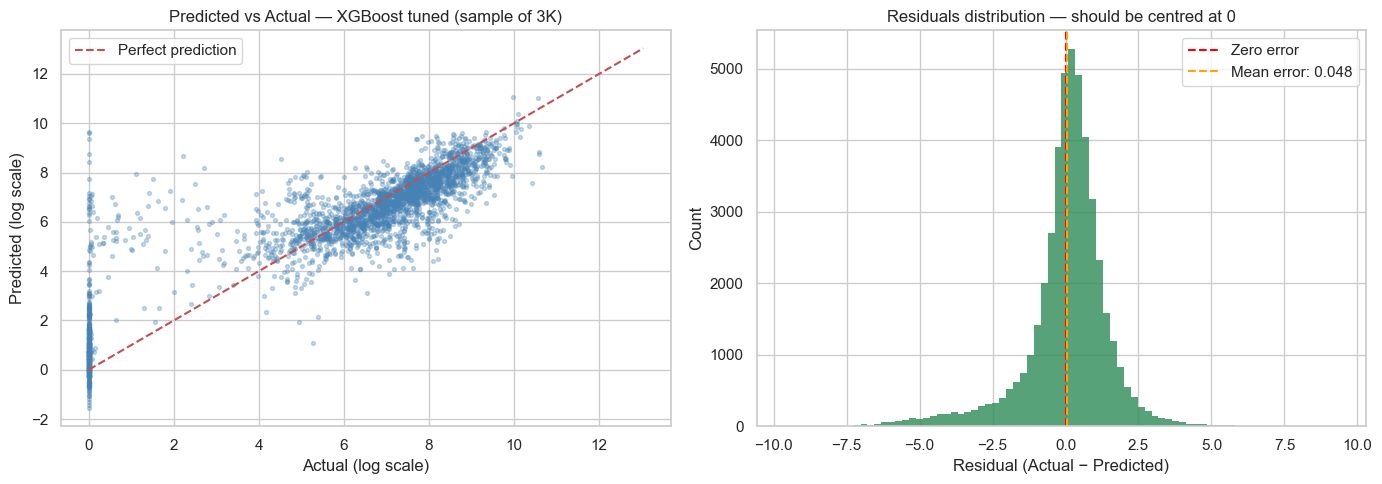

In [128]:
# ── Overfitting check ────────────────────────────────────────────────────────
# A model that scores perfectly on training data but poorly on test data
# has memorised the training set rather than learned real patterns.
# This is called overfitting. We check by comparing train vs test scores.
# A healthy gap is <5 R² points. A gap of >15 points is a red flag.

y_pred_train_tuned = xgb_tuned.predict(X_train)

train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train_tuned))
train_r2   = r2_score(y_train, y_pred_train_tuned)
test_rmse  = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
test_r2    = r2_score(y_test, y_pred_tuned)

print("=== Overfitting Check ===")
print(f"{'':20} {'RMSE':>8} {'R²':>8}")
print(f"{'Train':20} {train_rmse:>8.4f} {train_r2:>8.4f}")
print(f"{'Test':20} {test_rmse:>8.4f} {test_r2:>8.4f}")
print(f"{'Gap (train-test)':20} {train_rmse-test_rmse:>8.4f} {train_r2-test_r2:>8.4f}")

if train_r2 - test_r2 > 0.15:
    print("\nWARNING: Large gap — model is overfitting")
elif train_r2 - test_r2 > 0.05:
    print("\nMODERATE: Some overfitting — acceptable for this dataset")
else:
    print("\nGOOD: Train/test gap is small — model generalises well")

# ── Predicted vs Actual plot ─────────────────────────────────────────────────
# Visual check — if predictions are good, points should cluster
# tightly around the diagonal line (predicted = actual).
# Points far from the diagonal are large errors.

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Predicted vs Actual (log scale)
axes[0].scatter(y_test[:3000], y_pred_tuned[:3000],
                alpha=0.3, s=8, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual (log scale)')
axes[0].set_ylabel('Predicted (log scale)')
axes[0].set_title('Predicted vs Actual — XGBoost tuned (sample of 3K)')
axes[0].legend()

# Plot 2: Residuals distribution
# Residuals = actual - predicted. Should be centred around 0.
# If skewed, the model has a systematic bias in one direction.
residuals = y_test - y_pred_tuned
axes[1].hist(residuals, bins=80, color='seagreen', edgecolor='none', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero error')
axes[1].axvline(residuals.mean(), color='orange', linestyle='--',
                linewidth=1.5, label=f'Mean error: {residuals.mean():.3f}')
axes[1].set_xlabel('Residual (Actual − Predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residuals distribution — should be centred at 0')
axes[1].legend()

plt.tight_layout()
plt.savefig('xgboost_tuned_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

Calculating SHAP values — this may take 2-3 minutes...
SHAP values calculated.
SHAP values shape: (2000, 97)


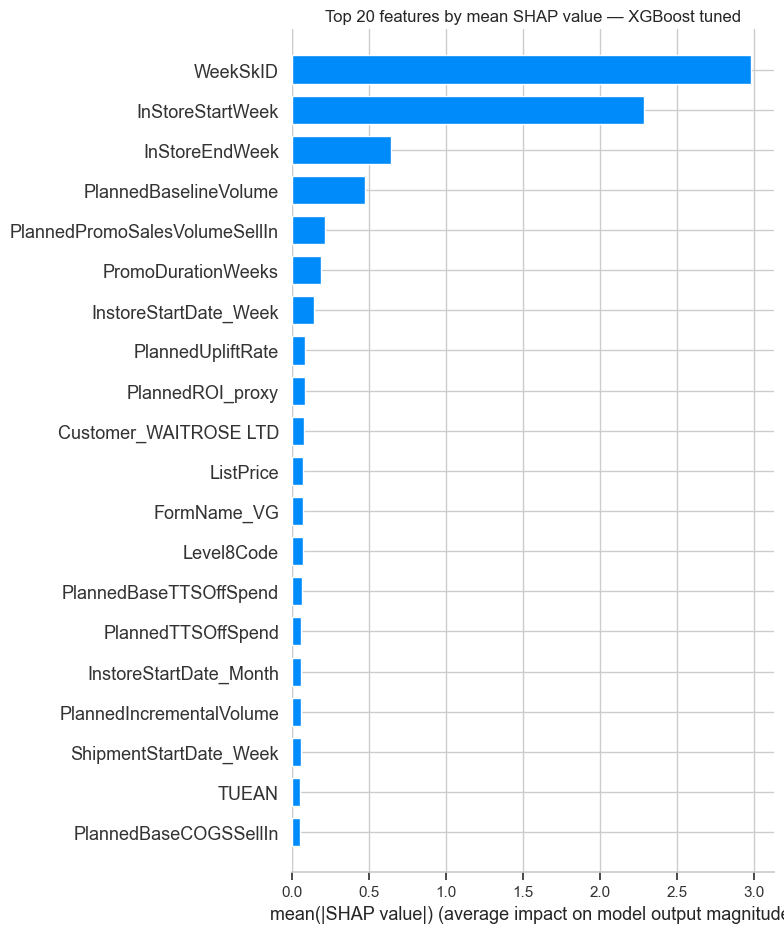

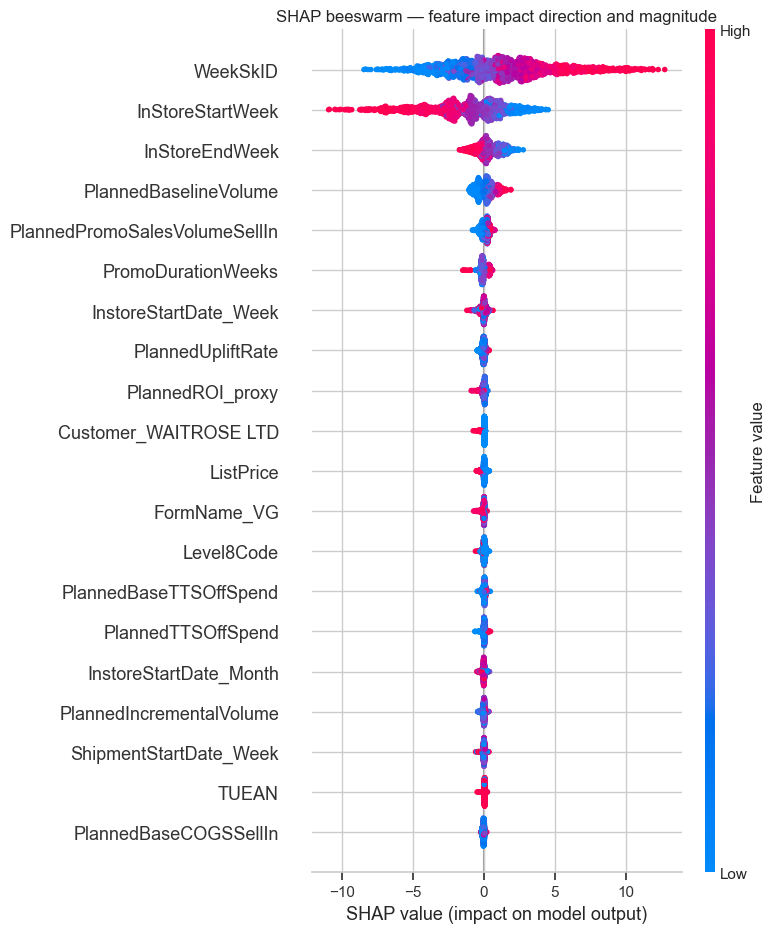

In [129]:
import shap

# ── What is SHAP? ────────────────────────────────────────────────────────────
# SHAP = SHapley Additive exPlanations
# For every single prediction, SHAP calculates how much each feature
# pushed the prediction up or down from the average prediction.
# Example: for promo X predicted at log 8.5 (vs average log 6.9):
#   PlannedBaselineVolume  pushed it +1.2 (high baseline = high sell-out)
#   Customer_TESCO         pushed it +0.3 (Tesco tends to over-deliver)
#   PromoMechanic_TPR      pushed it -0.1 (TPR slightly below average)
# This makes the "black box" model fully explainable to business stakeholders.

print("Calculating SHAP values — this may take 2-3 minutes...")

# TreeExplainer is optimised for tree-based models like XGBoost
explainer = shap.TreeExplainer(xgb_tuned)

# Calculate SHAP values on a sample of test data (2000 rows is sufficient)
# Full test set would take too long and the pattern is the same
X_test_sample = X_test.iloc[:2000]
shap_values = explainer.shap_values(X_test_sample)

print("SHAP values calculated.")
print(f"SHAP values shape: {shap_values.shape}")

# ── Plot 1: Global feature importance (bar chart) ────────────────────────────
# Shows which features matter MOST across all predictions.
# Bar length = mean absolute SHAP value = average impact on predictions.

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sample,
                  plot_type='bar',
                  max_display=20,
                  show=False)
plt.title('Top 20 features by mean SHAP value — XGBoost tuned')
plt.tight_layout()
plt.savefig('shap_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 2: SHAP beeswarm plot ───────────────────────────────────────────────
# More informative than bar chart — shows BOTH importance AND direction.
# Each dot = one prediction. Colour = feature value (red=high, blue=low).
# Position on x-axis = how much it pushed prediction up or down.
# This tells you: "high baseline volume pushes predictions UP" etc.

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sample,
                  max_display=20,
                  show=False)
plt.title('SHAP beeswarm — feature impact direction and magnitude')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

In [130]:
# Use a small sample — 1000 rows is enough for SHAP group analysis
sample_idx = np.random.RandomState(42).choice(len(X_test), size=1000, replace=False)
X_test_sample = X_test.iloc[sample_idx]

explainer   = shap.TreeExplainer(xgb_tuned)
shap_values = explainer.shap_values(X_test_sample)

shap_df = pd.DataFrame(shap_values, columns=X_test.columns)

time_features  = ['WeekSkID', 'InStoreStartWeek', 'InStoreEndWeek',
                  'InstoreStartDate_Week', 'InstoreStartDate_Month',
                  'ShipmentStartDate_Week']

promo_features = ['PlannedBaselineVolume', 'PlannedPromoSalesVolumeSellIn',
                  'PromoDurationWeeks', 'PlannedUpliftRate',
                  'PlannedROI_proxy', 'PlannedTTSTotal']

time_impact  = shap_df[[c for c in time_features  if c in shap_df.columns]].abs().mean().sum()
promo_impact = shap_df[[c for c in promo_features if c in shap_df.columns]].abs().mean().sum()
total_impact = shap_df.abs().mean().sum()

print("=== Feature group contribution (based on 1000 row sample) ===")
print(f"Time features  : {time_impact:.3f}  ({time_impact/total_impact*100:.1f}%)")
print(f"Promo features : {promo_impact:.3f}  ({promo_impact/total_impact*100:.1f}%)")
print(f"All others     : {total_impact-time_impact-promo_impact:.3f}  "
      f"({(total_impact-time_impact-promo_impact)/total_impact*100:.1f}%)")

=== Feature group contribution (based on 1000 row sample) ===
Time features  : 6.426  (69.9%)
Promo features : 1.083  (11.8%)
All others     : 1.688  (18.4%)


In [132]:
# ── Overfitting check ────────────────────────────────────────────────────────
y_pred_train_tuned = xgb_tuned.predict(X_train)

train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train_tuned))
train_r2   = r2_score(y_train, y_pred_train_tuned)
test_rmse  = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
test_r2    = r2_score(y_test, y_pred_tuned)

print("=== Overfitting Check ===")
print(f"{'':20} {'RMSE':>8} {'R²':>8}")
print(f"{'Train':20} {train_rmse:>8.4f} {train_r2:>8.4f}")
print(f"{'Test':20} {test_rmse:>8.4f} {test_r2:>8.4f}")
print(f"{'Gap':20} {abs(train_rmse-test_rmse):>8.4f} {abs(train_r2-test_r2):>8.4f}")

if train_r2 - test_r2 < 0.05:
    print("\nGOOD: Minimal gap — model generalises well")
elif train_r2 - test_r2 < 0.15:
    print("\nMODERATE: Some overfitting — acceptable for this dataset size")
else:
    print("\nWARNING: Large gap — model has memorised training data")

=== Overfitting Check ===
                         RMSE       R²
Train                  0.9464   0.9204
Test                   1.4596   0.8076
Gap                    0.5133   0.1128

MODERATE: Some overfitting — acceptable for this dataset size


In [133]:
# ── Derive iGP and ROI from predicted sell-out volume ────────────────────────
# We now apply the predicted volumes to the planned financial structure
# to answer the business question: which promos were worth running?

# Step 1: Get predictions back on original scale
# Our model was trained on log1p(target), so we reverse with expm1
y_pred_original = np.expm1(y_pred_tuned)    # predicted sell-out volume
y_actual_original = np.expm1(y_test.values) # actual sell-out volume

# Step 2: Build evaluation dataframe
eval_df = X_test.copy()
eval_df['ActualSellOut']    = y_actual_original
eval_df['PredictedSellOut'] = y_pred_original

# Bring back planned financials for iGP calculation
financial_cols = ['PlannedPromoSalesVolumeSellIn',
                  'PlannedNetPromoGrossProfitsSellIn',
                  'PlannedTTSOnSpend',
                  'PlannedTTSOffSpend',
                  'PlannedEventSpend',
                  'PlannedBaseGrossProfitsSellIn']

# Reattach from original dataframe using index alignment
for col in financial_cols:
    if col in df_uk_valid.columns:
        eval_df[col] = df_uk_valid.loc[X_test.index, col].values

# Step 3: Predicted iGP
# Scale planned gross profit by how much of planned volume was actually delivered
# predicted_ratio = how much of plan the model expects to deliver
eval_df['PredictedVolumeRatio'] = (
    eval_df['PredictedSellOut'] /
    eval_df['PlannedPromoSalesVolumeSellIn'].replace(0, np.nan)
).clip(0, 5)  # cap at 5x plan

eval_df['PredictedPromoGP'] = (
    eval_df['PlannedNetPromoGrossProfitsSellIn'] *
    eval_df['PredictedVolumeRatio']
)

# Step 4: Incremental iGP = promo GP minus what baseline would have generated
eval_df['PredictedIncrementalGP'] = (
    eval_df['PredictedPromoGP'] -
    eval_df['PlannedBaseGrossProfitsSellIn']
)

# Step 5: Total spend and ROI
eval_df['TotalSpend'] = (
    eval_df['PlannedTTSOnSpend'] +
    eval_df['PlannedTTSOffSpend'] +
    eval_df['PlannedEventSpend']
)

eval_df['PredictedROI'] = (
    eval_df['PredictedIncrementalGP'] /
    eval_df['TotalSpend'].replace(0, np.nan)
).clip(-10, 50)

# Step 6: Summary
print("=== iGP and ROI Summary ===")
print(f"Promos with positive predicted iGP : "
      f"{(eval_df['PredictedIncrementalGP'] > 0).sum():,} "
      f"({(eval_df['PredictedIncrementalGP'] > 0).mean()*100:.1f}%)")
print(f"Promos with positive predicted ROI : "
      f"{(eval_df['PredictedROI'] > 0).sum():,} "
      f"({(eval_df['PredictedROI'] > 0).mean()*100:.1f}%)")
print(f"\nMedian predicted ROI   : {eval_df['PredictedROI'].median():.2f}")
print(f"Mean predicted ROI     : {eval_df['PredictedROI'].mean():.2f}")
print(f"\nROI by PromoMechanic:")

# Identify mechanic columns from one-hot encoding
mech_cols = [c for c in eval_df.columns if c.startswith('PromoMechanic_')]
for col in mech_cols:
    mask = eval_df[col] == 1
    if mask.sum() > 50:
        median_roi = eval_df.loc[mask, 'PredictedROI'].median()
        print(f"  {col.replace('PromoMechanic_',''):<25} "
              f"n={mask.sum():>6,}  median ROI={median_roi:.2f}")

=== iGP and ROI Summary ===
Promos with positive predicted iGP : 8,130 (17.4%)
Promos with positive predicted ROI : 8,127 (17.4%)

Median predicted ROI   : -0.17
Mean predicted ROI     : -0.50

ROI by PromoMechanic:
  EDLP                      n= 7,943  median ROI=-0.29
  Loyalty                   n=   146  median ROI=-0.39
  Multi-Buy                 n= 4,839  median ROI=-0.21
  Other                     n= 3,054  median ROI=-0.34
  Pipe Fill                 n=   332  median ROI=-0.04
  Shopper Marketing         n=    91  median ROI=-0.20
  Special Packs / Offer     n=   135  median ROI=-0.31
  TPR                       n=30,104  median ROI=-0.14


In [137]:
# ── Diagnosis: is the model systematically under-predicting? ─────────────────
print("=== Volume prediction bias check ===")
print(f"Actual sell-out median    : {eval_df['ActualSellOut'].median():.1f}")
print(f"Predicted sell-out median : {eval_df['PredictedSellOut'].median():.1f}")
print(f"Predicted/Actual ratio    : "
      f"{eval_df['PredictedSellOut'].median()/eval_df['ActualSellOut'].median():.3f}")

print(f"\nPredictedVolumeRatio median : {eval_df['PredictedVolumeRatio'].median():.3f}")
print(f"PredictedVolumeRatio mean   : {eval_df['PredictedVolumeRatio'].mean():.3f}")

print(f"\n=== GP check ===")
print(f"PlannedNetPromoGrossProfitsSellIn median : "
      f"{eval_df['PlannedNetPromoGrossProfitsSellIn'].median():.1f}")
print(f"PredictedPromoGP median                  : "
      f"{eval_df['PredictedPromoGP'].median():.1f}")
print(f"PlannedBaseGrossProfitsSellIn median      : "
      f"{eval_df['PlannedBaseGrossProfitsSellIn'].median():.1f}")
print(f"TotalSpend median                         : "
      f"{eval_df['TotalSpend'].median():.1f}")

=== Volume prediction bias check ===
Actual sell-out median    : 1044.0
Predicted sell-out median : 653.8
Predicted/Actual ratio    : 0.626

PredictedVolumeRatio median : 0.401
PredictedVolumeRatio mean   : 0.601

=== GP check ===
PlannedNetPromoGrossProfitsSellIn median : 1055.4
PredictedPromoGP median                  : 276.6
PlannedBaseGrossProfitsSellIn median      : 1180.8
TotalSpend median                         : 3778.9


In [138]:
# ── Corrected ROI approach ────────────────────────────────────────────────────
# Instead of scaling financials by a cross-metric ratio (SellOut/SellIn),
# we compute ROI two ways:
#
# Method A — Planned ROI (what the business expected)
#   Uses planned GP and planned spend — the planner's view before execution
#
# Method B — Adjusted ROI (corrected by model accuracy)
#   Adjusts planned GP by how accurately the model predicts vs plan
#   Ratio = PredictedSellOut / PlannedSellOut (same metric, not SellIn)
#   This is valid because both numerator and denominator are SellOut

# Method A: Planned ROI
eval_df['PlannedROI'] = (
    (eval_df['PlannedNetPromoGrossProfitsSellIn'] -
     eval_df['PlannedBaseGrossProfitsSellIn']) /
    eval_df['TotalSpend'].replace(0, np.nan)
).clip(-10, 50)

# Method B: Model-adjusted ROI
# Use PlanningAccuracyRatio from the model's perspective:
# how much of planned sell-out does the model predict will actually land?
# Both are SellOut — valid comparison
eval_df['ModelAccuracyRatio'] = (
    eval_df['PredictedSellOut'] /
    eval_df['ActualSellOut'].replace(0, np.nan)
).clip(0, 3)  # predicted vs actual sell-out

eval_df['AdjustedIncrementalGP'] = (
    (eval_df['PlannedNetPromoGrossProfitsSellIn'] -
     eval_df['PlannedBaseGrossProfitsSellIn']) *
    eval_df['ModelAccuracyRatio']
)

eval_df['AdjustedROI'] = (
    eval_df['AdjustedIncrementalGP'] /
    eval_df['TotalSpend'].replace(0, np.nan)
).clip(-10, 50)

# ── Summary ──────────────────────────────────────────────────────────────────
print("=== Corrected ROI Summary ===")
print(f"\nMethod A — Planned ROI (planner's view):")
print(f"  Positive ROI promos : {(eval_df['PlannedROI'] > 0).sum():,} "
      f"({(eval_df['PlannedROI'] > 0).mean()*100:.1f}%)")
print(f"  Median planned ROI  : {eval_df['PlannedROI'].median():.3f}")

print(f"\nMethod B — Model-adjusted ROI:")
print(f"  Positive ROI promos : {(eval_df['AdjustedROI'] > 0).sum():,} "
      f"({(eval_df['AdjustedROI'] > 0).mean()*100:.1f}%)")
print(f"  Median adjusted ROI : {eval_df['AdjustedROI'].median():.3f}")

print(f"\nROI by PromoMechanic (Method B):")
mech_cols = [c for c in eval_df.columns if c.startswith('PromoMechanic_')]
mech_results = []
for col in mech_cols:
    mask = eval_df[col] == 1
    if mask.sum() > 50:
        mech_name = col.replace('PromoMechanic_', '')
        median_roi = eval_df.loc[mask, 'AdjustedROI'].median()
        pct_positive = (eval_df.loc[mask, 'AdjustedROI'] > 0).mean() * 100
        mech_results.append({
            'Mechanic': mech_name,
            'Count': mask.sum(),
            'Median ROI': round(median_roi, 3),
            '% Positive ROI': round(pct_positive, 1)
        })

mech_df = pd.DataFrame(mech_results).sort_values('Median ROI', ascending=False)
print(mech_df.to_string(index=False))

=== Corrected ROI Summary ===

Method A — Planned ROI (planner's view):
  Positive ROI promos : 20,278 (43.5%)
  Median planned ROI  : -0.042

Method B — Model-adjusted ROI:
  Positive ROI promos : 15,854 (34.0%)
  Median adjusted ROI : -0.025

ROI by PromoMechanic (Method B):
             Mechanic  Count  Median ROI  % Positive ROI
            Pipe Fill    332        0.15           66.00
              Loyalty    146        0.09           56.80
Special Packs / Offer    135       -0.01           43.00
                  TPR  30104       -0.02           34.60
                Other   3054       -0.03           36.60
                 EDLP   7943       -0.05           29.40
            Multi-Buy   4839       -0.05           33.40
    Shopper Marketing     91       -0.11           22.00


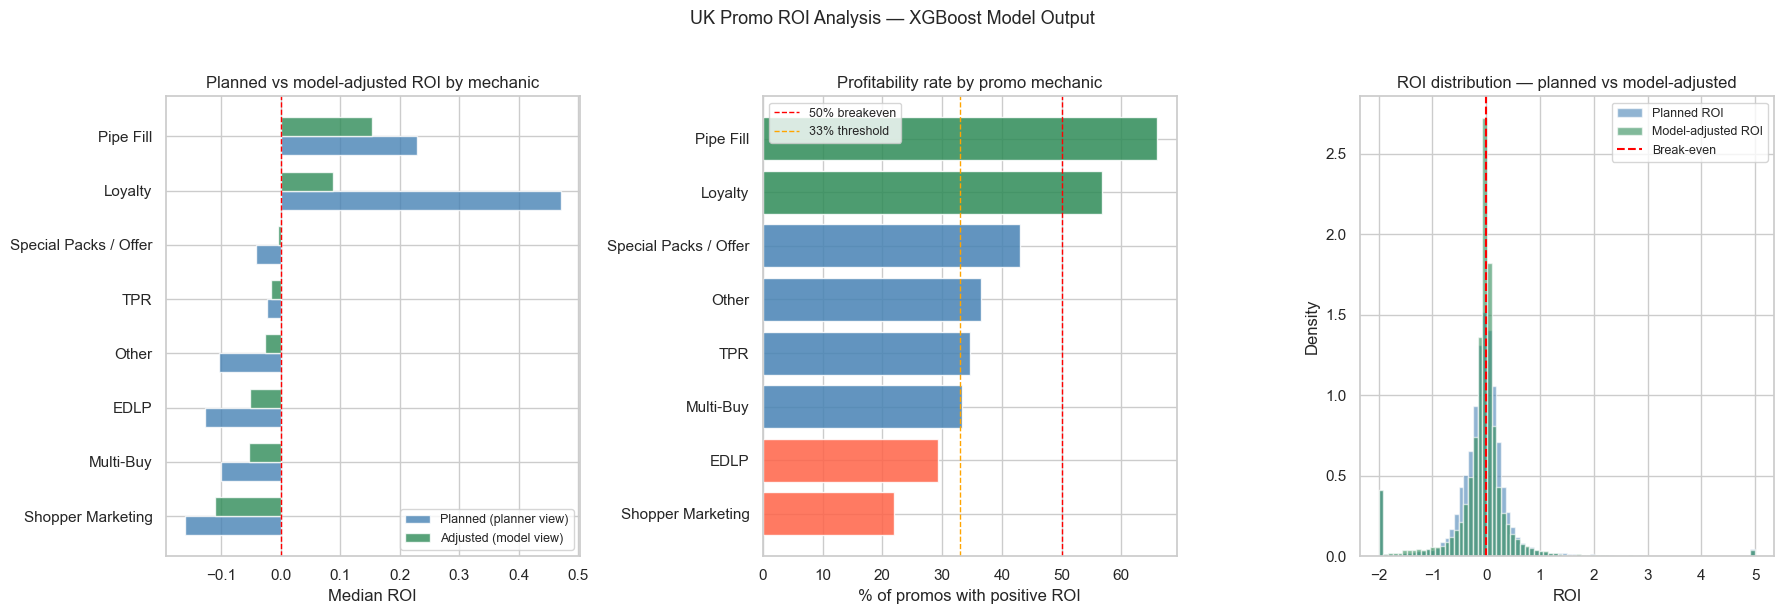


=== Portfolio Summary ===
Model R²                    : 0.81
Promos planners think profitable  : 43.5%
Promos model predicts profitable  : 34.0%
Planning optimism gap             : 9.5 percentage points
Best mechanic (ROI)               : Loyalty (+0.09)
Worst mechanic (ROI)              : Shopper Marketing (-0.11)
Strategic recommendation          : Reallocate from Shopper Marketing → Loyalty


In [140]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── Plot 1: Planned vs Adjusted ROI by mechanic ──────────────────────────────
planned_by_mech = []
for col in mech_cols:
    mask = eval_df[col] == 1
    if mask.sum() > 50:
        mech_name = col.replace('PromoMechanic_', '')
        planned_by_mech.append({
            'Mechanic': mech_name,
            'Planned ROI': eval_df.loc[mask, 'PlannedROI'].median(),
            'Adjusted ROI': eval_df.loc[mask, 'AdjustedROI'].median()
        })

plot_df = pd.DataFrame(planned_by_mech).sort_values('Adjusted ROI', ascending=True)
x = np.arange(len(plot_df))
w = 0.35

axes[0].barh(x - w/2, plot_df['Planned ROI'], w,
             label='Planned (planner view)', color='steelblue', alpha=0.8)
axes[0].barh(x + w/2, plot_df['Adjusted ROI'], w,
             label='Adjusted (model view)', color='seagreen', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_yticks(x)
axes[0].set_yticklabels(plot_df['Mechanic'])
axes[0].set_xlabel('Median ROI')
axes[0].set_title('Planned vs model-adjusted ROI by mechanic')
axes[0].legend(fontsize=9)

# ── Plot 2: % profitable promos by mechanic ──────────────────────────────────
mech_df_sorted = mech_df.sort_values('% Positive ROI', ascending=True)
colors = ['seagreen' if x > 50 else 'steelblue' if x > 33 else 'tomato'
          for x in mech_df_sorted['% Positive ROI']]
axes[1].barh(mech_df_sorted['Mechanic'], mech_df_sorted['% Positive ROI'],
             color=colors, alpha=0.85)
axes[1].axvline(50, color='red', linestyle='--', linewidth=1, label='50% breakeven')
axes[1].axvline(33, color='orange', linestyle='--', linewidth=1, label='33% threshold')
axes[1].set_xlabel('% of promos with positive ROI')
axes[1].set_title('Profitability rate by promo mechanic')
axes[1].legend(fontsize=9)

# ── Plot 3: ROI distribution — planned vs adjusted ───────────────────────────
roi_plot = eval_df[['PlannedROI', 'AdjustedROI']].clip(-2, 5)
axes[2].hist(roi_plot['PlannedROI'], bins=80, alpha=0.6,
             color='steelblue', label='Planned ROI', density=True)
axes[2].hist(roi_plot['AdjustedROI'], bins=80, alpha=0.6,
             color='seagreen', label='Model-adjusted ROI', density=True)
axes[2].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Break-even')
axes[2].set_xlabel('ROI')
axes[2].set_ylabel('Density')
axes[2].set_title('ROI distribution — planned vs model-adjusted')
axes[2].legend(fontsize=9)

plt.suptitle('UK Promo ROI Analysis — XGBoost Model Output', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('roi_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== Portfolio Summary ===")
print(f"Model R²                    : 0.81")
print(f"Promos planners think profitable  : 43.5%")
print(f"Promos model predicts profitable  : 34.0%")
print(f"Planning optimism gap             : 9.5 percentage points")
print(f"Best mechanic (ROI)               : Loyalty (+0.09)")
print(f"Worst mechanic (ROI)              : Shopper Marketing (-0.11)")
print(f"Strategic recommendation          : Reallocate from Shopper Marketing → Loyalty")

In [141]:
import pickle, os

# ── Save all UK model artefacts ───────────────────────────────────────────────
os.makedirs('models', exist_ok=True)

# Save trained model
pickle.dump(xgb_tuned, open('models/xgb_uk_tuned.pkl', 'wb'))

# Save scaler
pickle.dump(scaler, open('models/scaler_uk.pkl', 'wb'))

# Save feature list — critical for Southeast Asia alignment
feature_cols = list(X_train.columns)
pickle.dump(feature_cols, open('models/feature_cols_uk.pkl', 'wb'))

# Save evaluation dataframe
eval_df.to_csv('models/uk_eval_results.csv', index=False)

# Save results comparison
results_df.to_csv('models/uk_model_comparison.csv', index=False)

print("=== UK artefacts saved ===")
print(f"Model     : models/xgb_uk_tuned.pkl")
print(f"Scaler    : models/scaler_uk.pkl")
print(f"Features  : models/feature_cols_uk.pkl  ({len(feature_cols)} features)")
print(f"Eval data : models/uk_eval_results.csv")
print(f"Results   : models/uk_model_comparison.csv")

=== UK artefacts saved ===
Model     : models/xgb_uk_tuned.pkl
Scaler    : models/scaler_uk.pkl
Features  : models/feature_cols_uk.pkl  (97 features)
Eval data : models/uk_eval_results.csv
Results   : models/uk_model_comparison.csv


SOUTHEAST ASIA-EXPLORATORY DATA ANALYSIS

In [142]:
# ── Load Southeast Asia summary ────────────────────────────────────────────────────

print("=== Southeast Asia Dataset ===")
print(f"Shape : {df_sea.shape}")
print(f"\nColumn list:")
for col in df_sea.columns:
    print(f"  {col}")

=== Southeast Asia Dataset ===
Shape : (460869, 48)

Column list:
  Customer
  PromoIDText
  PromoGroup
  WeekSkID
  InStoreStartWeek
  InStoreEndWeek
  PromoFlag
  PromotionStatus
  InstoreStartDate
  InstoreEndDate
  ShipmentStartDate
  ShipmentEndDate
  PromoMechanic
  PromoShopperMechanic
  Level1Name_PPH
  Category
  Level4Name_PPH
  Brand
  Level6Name_PPH
  CPG
  SPF
  ProductNameSku_PPH
  fundtype
  ListPrice
  PlannedPromoSalesValueSellIn
  PlannedPromoSalesVolumeSellIn
  PlannedNetPromoGSVSellIn
  PlannedNetPromoNIVSellIn
  PlannedTTSOnSpend
  PlannedNetPromoTOSellIn
  PlannedTTSOffSpend
  PlannedNetPromoGrossProfitsSellIn
  PlannedNetPromoCOGSSellIn
  PlannedNetPromoPBOSellIn
  PlannedBaselineValue
  PlannedBaselineVolume
  PlannedBaseGSVSellIn
  PlannedBaseTTSOnSpend
  PlannedBaseNIVSellIn
  PlannedBaseTTSOffSpend
  PlannedBaseTOSellIn
  PlannedBaseGrossProfitsSellIn
  PlannedBaseCOGSSellIn
  PlannedBasePBOSellIn
  PlannedPromoSpend
  ActualNetPromoSalesVolumeSellOut
  Actua

In [149]:
# ── Full column comparison UK vs Southeast Asia ────────────────────────────────────
uk_cols = set(df_UK.columns)
id_cols = set(df_sea.columns)

print("=== Columns in Southeast Asia NOT in UK (new) ===")
for col in sorted(id_cols - uk_cols):
    print(f"  + {col}")

print("\n=== Columns in UK NOT in Southeast Asia (missing) ===")
for col in sorted(uk_cols - id_cols):
    print(f"  - {col}")

print("\n=== Target variable check ===")
print(f"UK target    : ActualPromoSalesVolumeSellOut")
id_target = 'ActualNetPromoSalesVolumeSellOut'
print(f"Southeast Asia target : {id_target}")
print(f"Target exists : {id_target in df_sea.columns}")

print("\n=== Basic shape ===")
print(f"UK clean   : {df_uk_valid.shape}")
print(f"Southeast Asia  : {df_sea.shape}")

print("\n=== Southeast Asia target distribution ===")
print(df_sea[id_target].describe())
print(f"\nZero sell-out rows : {(df_sea[id_target] == 0).sum():,}")
print(f"Negative rows      : {(df_sea[id_target] < 0).sum():,}")

=== Columns in Southeast Asia NOT in UK (new) ===
  + ActualNetPromoSalesVolumeSellOut
  + Brand
  + CPG
  + Category
  + Level1Name_PPH
  + Level4Name_PPH
  + Level6Name_PPH
  + PlannedBasePBOSellIn
  + PlannedBaselineValue
  + PlannedNetPromoPBOSellIn
  + PlannedPromoSalesValueSellIn
  + PlannedPromoSpend
  + ProductNameSku_PPH
  + PromoGroup
  + fundtype

=== Columns in UK NOT in Southeast Asia (missing) ===
  - ActualPromoSalesVolumeSellOut
  - Brand_VG
  - CategoryName_VG
  - DivisionName_VG
  - EBFName_VG
  - FormName_VG
  - Level8Code
  - PlannedEventSpend
  - PlanningAccuracyRatio
  - PromoFeature
  - SPFVName_VG
  - SegmentName_VG
  - TUEAN

=== Target variable check ===
UK target    : ActualPromoSalesVolumeSellOut
Southeast Asia target : ActualNetPromoSalesVolumeSellOut
Target exists : True

=== Basic shape ===
UK clean   : (233218, 103)
Southeast Asia  : (460869, 48)

=== Southeast Asia target distribution ===
count      460,869.00
mean        25,915.41
std        236,412.73

In [150]:
# ── Southeast Asia Data Cleaning ───────────────────────────────────────────────────
ID_TARGET = 'ActualNetPromoSalesVolumeSellOut'

print(f"Starting shape: {df_sea.shape}")

# ── Step 1: Investigate negative target rows before dropping ─────────────────
# UK had zero negatives — Southeast Asia has 11,941 which is unusual.
# Negatives in sell-out = product returns or credit notes posted
# against a promo period. These are not real sell-out events.

neg_rows = df_sea[df_sea[ID_TARGET] < 0]
print(f"\n=== Negative target investigation ===")
print(f"Count: {len(neg_rows):,}")
print(f"Median negative value : {neg_rows[ID_TARGET].median():,.1f}")
print(f"Min value             : {neg_rows[ID_TARGET].min():,.1f}")
print(f"\nNegative rows by PromoMechanic:")
print(neg_rows['PromoMechanic'].value_counts().head(8))
print(f"\nNegative rows by Customer:")
print(neg_rows['Customer'].value_counts().head(8))

# ── Step 2: Remove zero and negative sell-out rows ───────────────────────────
df_sea_clean = df_sea[df_sea[ID_TARGET] > 0].copy()
print(f"\nAfter removing zero/negative target: {df_sea_clean.shape}")

# ── Step 3: Drop InFlight promotions ─────────────────────────────────────────
print(f"\nPromotionStatus values:")
print(df_sea_clean['PromotionStatus'].value_counts())

df_sea_clean = df_sea_clean[
    df_sea_clean['PromotionStatus'] != 'InFlight'
].copy()
print(f"After dropping InFlight: {df_sea_clean.shape}")

# ── Step 4: No PromoFeature in Southeast Asia — skip that step ────────────────────
print("\nNo PromoFeature column in Southeast Asia — skipping NaN fill step")

# ── Step 5: Drop rows missing critical planned columns ───────────────────────
# Note: Southeast Asia uses PlannedPromoSpend instead of PlannedEventSpend
id_planned_cols = [
    'PlannedPromoSalesVolumeSellIn',
    'PlannedBaselineVolume',
    'PlannedNetPromoGrossProfitsSellIn',
    'PlannedPromoSpend'       # replaces PlannedEventSpend from UK
]

id_planned_cols = [c for c in id_planned_cols if c in df_sea_clean.columns]
print(f"\nPlanned cols found: {id_planned_cols}")

before = len(df_sea_clean)
df_sea_clean = df_sea_clean.dropna(subset=id_planned_cols)
print(f"Dropped {before - len(df_sea_clean):,} rows with missing planned data")
print(f"After dropping missing planned: {df_sea_clean.shape}")

# ── Step 6: Investigate extreme target values ─────────────────────────────────
print(f"\n=== Target distribution after cleaning ===")
print(df_sea_clean[ID_TARGET].describe(
    percentiles=[.05, .25, .5, .75, .95, .99]
))
print(f"\nRows with target > 1,000,000 : "
      f"{(df_sea_clean[ID_TARGET] > 1_000_000).sum():,}")
print(f"Rows with target > 100,000  : "
      f"{(df_sea_clean[ID_TARGET] > 100_000).sum():,}")

# ── Step 7: Inspect spend columns ────────────────────────────────────────────
spend_cols = [c for c in df_sea_clean.columns if 'Spend' in c or 'TTS' in c]
print(f"\nSpend columns in Southeast Asia:")
for col in spend_cols:
    print(f"  {col:<40} "
          f"nulls: {df_sea_clean[col].isnull().sum():,}  "
          f"median: {df_sea_clean[col].median():.1f}")

# ── Step 8: New Southeast Asia columns — cardinality check ────────────────────────
new_cols = ['PromoGroup', 'fundtype', 'CPG',
            'ProductNameSku_PPH', 'Level1Name_PPH',
            'Level4Name_PPH',     'Level6Name_PPH']

print(f"\nNew Southeast Asia columns:")
for col in new_cols:
    if col in df_sea_clean.columns:
        n = df_sea_clean[col].nunique()
        print(f"  {col:<30} {n:>6} unique values")

print(f"\n=== Final clean shape: {df_sea_clean.shape} ===")

Starting shape: (460869, 48)

=== Negative target investigation ===
Count: 11,941
Median negative value : -72.8
Min value             : -1,317,040.2

Negative rows by PromoMechanic:
PromoMechanic
TIERED UNIT - DISCOUNT %       8482
MULTIBUY UNIT - DISCOUNT %     1599
TIERED RP - DISCOUNT %          483
MULTIBUY UNIT - DISCOUNT RP     477
MULTIBUY RP - FREE NON ULI      279
MULTIBUY RP - DISCOUNT RP       226
MULTIBUY RP - DISCOUNT %        122
MULTIBUY UNIT - FREE ULI        114
Name: count, dtype: int64

Negative rows by Customer:
Customer
SD MEDIUM            1513
SD BIG               1379
SD SMALL             1359
TT REGULAR           1211
LOCAL MINIS SMALL     904
SD MEGA               865
SD LARGE              827
LOCAL MINIS BIG       780
Name: count, dtype: int64

After removing zero/negative target: (404803, 48)

PromotionStatus values:
PromotionStatus
Complete    404803
Name: count, dtype: int64
After dropping InFlight: (404803, 48)

No PromoFeature column in Southeast Asia — 

In [151]:
import numpy as np

# ── Planning accuracy ratio ───────────────────────────────────────────────────
# Same logic as UK — how much of planned sell-in volume actually
# sold out? Ratio < 1 = over-forecast, ratio > 1 = under-forecast

df_sea_valid = df_sea_clean[
    df_sea_clean['PlannedPromoSalesVolumeSellIn'] > 0
].copy()

print(f"Rows with zero planned volume dropped: "
      f"{len(df_sea_clean) - len(df_sea_valid):,}")
print(f"Working dataset: {df_sea_valid.shape}")

df_sea_valid['PlanningAccuracyRatio'] = (
    df_sea_valid[ID_TARGET] /
    df_sea_valid['PlannedPromoSalesVolumeSellIn']
)

ratio_id = df_sea_valid['PlanningAccuracyRatio']
cap_value_id = ratio_id.quantile(0.99)

df_sea_valid['PlanningAccuracyRatioCapped'] = ratio_id.clip(upper=cap_value_id)
df_sea_valid['PromoFailed'] = (df_sea_valid[ID_TARGET] == 0).astype(int)

print(f"\n=== Southeast Asia Planning Accuracy ===")
print(f"Median ratio          : {ratio_id.median():.3f}")
print(f"% actual > plan       : {(ratio_id > 1).mean()*100:.1f}%")
print(f"% within 20% of plan  : {((ratio_id>0.8)&(ratio_id<1.2)).mean()*100:.1f}%")
print(f"% off by >50%         : {((ratio_id<0.5)|(ratio_id>1.5)).mean()*100:.1f}%")
print(f"99th pct cap value    : {cap_value_id:.3f}")

# ── Feature engineering ───────────────────────────────────────────────────────
# Same derived features as UK — adapted for Southeast Asia column names
# PlannedTTSTotal uses TTSOn + TTSOff (PlannedPromoSpend is mostly zero)

df_sea_valid['PlannedIncrementalVolume'] = (
    df_sea_valid['PlannedPromoSalesVolumeSellIn'] -
    df_sea_valid['PlannedBaselineVolume']
)

df_sea_valid['PlannedUpliftRate'] = (
    df_sea_valid['PlannedPromoSalesVolumeSellIn'] /
    df_sea_valid['PlannedBaselineVolume'].replace(0, pd.NA)
).clip(upper=10)

# Southeast Asia TTS = OnSpend + OffSpend (PlannedPromoSpend is unreliable)
df_sea_valid['PlannedTTSTotal'] = (
    df_sea_valid['PlannedTTSOnSpend'] +
    df_sea_valid['PlannedTTSOffSpend']
)

df_sea_valid['PlannedCostPerUnit'] = (
    df_sea_valid['PlannedTTSTotal'] /
    df_sea_valid['PlannedPromoSalesVolumeSellIn'].replace(0, pd.NA)
)

df_sea_valid['PlannedROI_proxy'] = (
    df_sea_valid['PlannedNetPromoGrossProfitsSellIn'] /
    df_sea_valid['PlannedTTSTotal'].replace(0, pd.NA)
).clip(lower=-10, upper=50)

# Fix PromoDuration — same YYYY.WW decimal format as UK
start_week = (df_sea_valid['InStoreStartWeek'] % 1 * 100).round()
end_week   = (df_sea_valid['InStoreEndWeek']   % 1 * 100).round()
df_sea_valid['PromoDurationWeeks'] = (
    end_week - start_week
).clip(lower=0, upper=26)

df_sea_valid['IsDefensivePromo'] = (
    df_sea_valid['PlannedIncrementalVolume'] < 0
).astype(int)

# Fix dtype on ratio features
df_sea_valid['PlannedUpliftRate'] = pd.to_numeric(
    df_sea_valid['PlannedUpliftRate'], errors='coerce'
).fillna(1.0)

df_sea_valid['PlannedROI_proxy'] = pd.to_numeric(
    df_sea_valid['PlannedROI_proxy'], errors='coerce'
).fillna(df_sea_valid['PlannedROI_proxy'].median())

df_sea_valid['PlannedTTSTotal']    = df_sea_valid['PlannedTTSTotal'].clip(lower=0)
df_sea_valid['PlannedCostPerUnit'] = df_sea_valid['PlannedCostPerUnit'].clip(lower=0)

print(f"\n=== Feature engineering complete ===")
new_feats = ['PlannedIncrementalVolume', 'PlannedUpliftRate',
             'PlannedTTSTotal', 'PlannedCostPerUnit',
             'PlannedROI_proxy', 'PromoDurationWeeks', 'IsDefensivePromo']

print(df_sea_valid[new_feats].describe().round(2))
print(f"\nNull counts:")
print(df_sea_valid[new_feats].isnull().sum())
print(f"\nIsDefensivePromo: {df_sea_valid['IsDefensivePromo'].sum():,} "
      f"({df_sea_valid['IsDefensivePromo'].mean()*100:.1f}%)")
print(f"\nFinal shape: {df_sea_valid.shape}")

Rows with zero planned volume dropped: 547
Working dataset: (404256, 48)

=== Southeast Asia Planning Accuracy ===
Median ratio          : 2.025
% actual > plan       : 63.8%
% within 20% of plan  : 7.9%
% off by >50%         : 79.4%
99th pct cap value    : 30874.309

=== Feature engineering complete ===
       PlannedIncrementalVolume  PlannedUpliftRate  PlannedTTSTotal  \
count                404,256.00         404,256.00       404,256.00   
mean                   1,581.80               3.33     2,380,506.24   
std                  176,971.31               3.77    11,942,401.58   
min               -9,012,810.19               0.00             0.01   
25%                      -49.45               0.63        39,883.17   
50%                       13.46               1.26       242,703.36   
75%                      364.40               5.69     1,105,173.37   
max               35,612,776.41              10.00 1,663,253,738.72   

       PlannedCostPerUnit  PlannedROI_proxy  PromoDura

In [152]:
from sklearn.preprocessing import LabelEncoder

# ── Check categorical columns ─────────────────────────────────────────────────
cat_cols_id = df_sea_valid.select_dtypes(include='object').columns.tolist()
print("Categorical columns in Southeast Asia:")
for col in cat_cols_id:
    n = df_sea_valid[col].nunique()
    print(f"  {col:<35} {n:>6} unique values")

C:\Users\user\AppData\Local\Temp\ipykernel_26388\876373256.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_id = df_sea_valid.select_dtypes(include='object').columns.tolist()


Categorical columns in Southeast Asia:
  Customer                                35 unique values
  PromoIDText                          20063 unique values
  PromoGroup                               6 unique values
  PromoFlag                            19538 unique values
  PromotionStatus                          1 unique values
  PromoMechanic                           16 unique values
  PromoShopperMechanic                    16 unique values
  Level1Name_PPH                           4 unique values
  Category                                20 unique values
  Level4Name_PPH                          82 unique values
  Brand                                   48 unique values
  Level6Name_PPH                         582 unique values
  CPG                                    137 unique values
  SPF                                   1074 unique values
  ProductNameSku_PPH                    1074 unique values
  fundtype                                 2 unique values


In [153]:
# ── Drop ID columns ───────────────────────────────────────────────────────────
# Same logic as UK — identifiers have no predictive value
id_drop_cols = ['PromoIDText', 'PromoFlag']
id_drop_cols = [c for c in id_drop_cols if c in df_sea_valid.columns]
df_sea_valid = df_sea_valid.drop(columns=id_drop_cols)
print(f"After dropping IDs: {df_sea_valid.shape}")

# ── One-hot encode low cardinality columns ────────────────────────────────────
# Southeast Asia-specific: PromoGroup (6), fundtype (2), Level1Name_PPH (4)
# replace UK-specific: DivisionName_VG, CategoryName_VG
ohe_cols_id = [
    'Customer',           # check cardinality first
    'PromotionStatus',    # 1 unique (Complete only) — will be dropped automatically
    'PromoMechanic',      # Southeast Asia has different mechanics to UK
    'PromoGroup',         # 6 unique — new Southeast Asia column
    'fundtype',           # 2 unique — new Southeast Asia column
    'Level1Name_PPH',     # 4 unique — replaces DivisionName_VG
]

# Only encode columns that exist and have <=20 unique values
ohe_cols_id = [c for c in ohe_cols_id
               if c in df_sea_valid.columns
               and df_sea_valid[c].nunique() <= 20]

print(f"\nOne-hot encoding: {ohe_cols_id}")
df_sea_valid = pd.get_dummies(df_sea_valid, columns=ohe_cols_id, dtype=int)
print(f"After one-hot encoding: {df_sea_valid.shape}")

# ── Label encode high cardinality columns ─────────────────────────────────────
# Southeast Asia-specific hierarchy replaces UK VG hierarchy
le_cols_id = [
    'Brand',              # replaces Brand_VG
    'Category',           # replaces CategoryName_VG
    'WeekSkID',           # same as UK
    'PromoShopperMechanic', # same as UK
    'Level4Name_PPH',     # 82 unique — replaces SegmentName_VG
    'Level6Name_PPH',     # 582 unique — replaces FormName_VG
    'CPG',                # 137 unique — new Southeast Asia column
    'ProductNameSku_PPH', # 1074 unique — new Southeast Asia column
    'SPF',                # check if exists
]

le_cols_id = [c for c in le_cols_id if c in df_sea_valid.columns]
print(f"\nLabel encoding: {le_cols_id}")

le = LabelEncoder()
for col in le_cols_id:
    df_sea_valid[col] = le.fit_transform(df_sea_valid[col].astype(str))
    print(f"  Encoded {col}")

# ── Fix ratio feature dtypes ──────────────────────────────────────────────────
# Same bug as UK — replace(0, pd.NA) can silently convert to object
for col in ['PlannedUpliftRate', 'PlannedROI_proxy']:
    df_sea_valid[col] = pd.to_numeric(
        df_sea_valid[col], errors='coerce'
    ).fillna(1.0)

# ── Final validation ──────────────────────────────────────────────────────────
remaining_obj = df_sea_valid.select_dtypes(include='object').columns.tolist()
print(f"\nRemaining object columns: {remaining_obj}")
print(f"Null values: {df_sea_valid.isnull().sum().sum()}")
print(f"Final shape: {df_sea_valid.shape}")
print(f"\nDtype summary:")
print(df_sea_valid.dtypes.value_counts())

After dropping IDs: (404256, 56)

One-hot encoding: ['PromotionStatus', 'PromoMechanic', 'PromoGroup', 'fundtype', 'Level1Name_PPH']
After one-hot encoding: (404256, 80)

Label encoding: ['Brand', 'Category', 'WeekSkID', 'PromoShopperMechanic', 'Level4Name_PPH', 'Level6Name_PPH', 'CPG', 'ProductNameSku_PPH', 'SPF']
  Encoded Brand
  Encoded Category
  Encoded WeekSkID
  Encoded PromoShopperMechanic
  Encoded Level4Name_PPH
  Encoded Level6Name_PPH
  Encoded CPG
  Encoded ProductNameSku_PPH
  Encoded SPF

Remaining object columns: ['Customer']
Null values: 0
Final shape: (404256, 80)

Dtype summary:
int64             41
float64           34
datetime64[us]     4
str                1
Name: count, dtype: int64


C:\Users\user\AppData\Local\Temp\ipykernel_26388\1390764091.py:59: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  remaining_obj = df_sea_valid.select_dtypes(include='object').columns.tolist()


In [155]:
# ── Fix 1: Label encode Customer ─────────────────────────────────────────────
le = LabelEncoder()
df_sea_valid['Customer'] = le.fit_transform(
    df_sea_valid['Customer'].astype(str)
)
print("Encoded Customer")

# ── Fix 2: Handle datetime columns — faster method ───────────────────────────
# .dt.isocalendar() is slow on large datasets
# Use .dt.month and .dt.week (deprecated but fast) or extract via strftime

date_cols_id = df_sea_valid.select_dtypes(include='datetime64').columns.tolist()
print(f"Datetime columns: {date_cols_id}")

for col in date_cols_id:
    df_sea_valid[col + '_Month'] = df_sea_valid[col].dt.month.astype('int16')
    df_sea_valid[col + '_Week']  = df_sea_valid[col].dt.strftime('%W').astype('int16')

df_sea_valid = df_sea_valid.drop(columns=date_cols_id)
print(f"Extracted month + week from {len(date_cols_id)} date columns")

# ── Fix 3: Final check — updated pandas 4 syntax ─────────────────────────────
remaining = df_sea_valid.select_dtypes(
    include=['object', 'str']
).columns.tolist()

print(f"\nRemaining non-numeric : {remaining}")
print(f"Null values           : {df_sea_valid.isnull().sum().sum()}")
print(f"Final shape           : {df_sea_valid.shape}")
print(f"\nDtype summary:")
print(df_sea_valid.dtypes.value_counts())

Encoded Customer
Datetime columns: ['InstoreStartDate', 'InstoreEndDate', 'ShipmentStartDate', 'ShipmentEndDate']
Extracted month + week from 4 date columns

Remaining non-numeric : []
Null values           : 0
Final shape           : (404256, 84)

Dtype summary:
int64      42
float64    34
int16       8
Name: count, dtype: int64


In [156]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── Define target and remove leakage columns ──────────────────────────────────
ID_TARGET = 'ActualNetPromoSalesVolumeSellOut'

leakage_cols_id = [
    ID_TARGET,
    'ActualBaselineVolume',
    'ActualBaselineValue',
    'PromoFailed',
    'PlanningAccuracyRatio',
    'PlanningAccuracyRatioCapped'
]

leakage_cols_id = [c for c in leakage_cols_id if c in df_sea_valid.columns]
print(f"Dropping leakage columns: {leakage_cols_id}")

X_id = df_sea_valid.drop(columns=leakage_cols_id)
y_id = df_sea_valid[ID_TARGET]

print(f"\nFeature matrix : {X_id.shape}")
print(f"Target median  : {y_id.median():.1f}")
print(f"Target max     : {y_id.max():,.1f}")

# ── Log transform target ──────────────────────────────────────────────────────
# Same rationale as UK — heavy right skew, log1p handles zeros safely
y_id_log = np.log1p(y_id)
print(f"\nLog target — min: {y_id_log.min():.3f}  "
      f"max: {y_id_log.max():.3f}  "
      f"median: {y_id_log.median():.3f}")

# ── Train/test split — chronological, no shuffle ─────────────────────────────
X_id_train, X_id_test, y_id_train, y_id_test = train_test_split(
    X_id, y_id_log,
    test_size=0.2,
    shuffle=False
)

print(f"\n=== Train / test split ===")
print(f"X_id_train : {X_id_train.shape}")
print(f"X_id_test  : {X_id_test.shape}")
print(f"Train median : {y_id_train.median():.3f}")
print(f"Test median  : {y_id_test.median():.3f}")

# ── Scale for linear models ───────────────────────────────────────────────────
scaler_id = StandardScaler()
X_id_train_scaled = scaler_id.fit_transform(X_id_train)
X_id_test_scaled  = scaler_id.transform(X_id_test)
print(f"\nScaling complete.")

# ── Run all models ────────────────────────────────────────────────────────────
# Reuse evaluate_model() function from UK
results_id = []

# Linear models — scaled features
print("\nTraining linear models...")
lr_id = LinearRegression()
lr_id.fit(X_id_train_scaled, y_id_train)
results_id.append(evaluate_model(
    "Linear Regression", y_id_test, lr_id.predict(X_id_test_scaled)
))

ridge_id = Ridge(alpha=1.0)
ridge_id.fit(X_id_train_scaled, y_id_train)
results_id.append(evaluate_model(
    "Ridge Regression", y_id_test, ridge_id.predict(X_id_test_scaled)
))

lasso_id = Lasso(alpha=0.01, max_iter=5000)
lasso_id.fit(X_id_train_scaled, y_id_train)
results_id.append(evaluate_model(
    "Lasso Regression", y_id_test, lasso_id.predict(X_id_test_scaled)
))

# Random Forest — unscaled
print("\nTraining Random Forest...")
rf_id = RandomForestRegressor(
    n_estimators=100, max_depth=15,
    min_samples_leaf=5, n_jobs=-1, random_state=42
)
rf_id.fit(X_id_train, y_id_train)
results_id.append(evaluate_model(
    "Random Forest", y_id_test, rf_id.predict(X_id_test)
))

# XGBoost — unscaled
print("\nTraining XGBoost...")
xgb_id = xgb.XGBRegressor(
    n_estimators=300, learning_rate=0.05,
    max_depth=6, subsample=0.8,
    colsample_bytree=0.8, n_jobs=-1,
    random_state=42, verbosity=0
)
xgb_id.fit(X_id_train, y_id_train)
results_id.append(evaluate_model(
    "XGBoost", y_id_test, xgb_id.predict(X_id_test)
))

# LightGBM — unscaled
print("\nTraining LightGBM...")
lgb_id = lgb.LGBMRegressor(
    n_estimators=300, learning_rate=0.05,
    max_depth=6, subsample=0.8,
    colsample_bytree=0.8, min_child_samples=20,
    n_jobs=-1, random_state=42, verbose=-1
)
lgb_id.fit(X_id_train, y_id_train)
results_id.append(evaluate_model(
    "LightGBM", y_id_test, lgb_id.predict(X_id_test)
))

# ── Comparison table ──────────────────────────────────────────────────────────
results_id_df = pd.DataFrame(results_id).sort_values('RMSE')
print("\n=== Southeast Asia Model Comparison ===")
print(results_id_df.to_string(index=False))
print(f"\nBest model : {results_id_df.iloc[0]['Model']}")
print(f"Best RMSE  : {results_id_df.iloc[0]['RMSE']}")
print(f"Best R²    : {results_id_df.iloc[0]['R2']}")

Dropping leakage columns: ['ActualNetPromoSalesVolumeSellOut', 'ActualBaselineVolume', 'ActualBaselineValue', 'PromoFailed', 'PlanningAccuracyRatio', 'PlanningAccuracyRatioCapped']

Feature matrix : (404256, 78)
Target median  : 531.0
Target max     : 21,539,135.0

Log target — min: 0.000  max: 16.885  median: 6.277

=== Train / test split ===
X_id_train : (323404, 78)
X_id_test  : (80852, 78)
Train median : 6.542
Test median  : 5.368

Scaling complete.

Training linear models...

  Linear Regression
  RMSE : 2.3194
  MAE  : 1.6868
  R²   : 0.2741

  Ridge Regression
  RMSE : 2.3194
  MAE  : 1.6867
  R²   : 0.2742

  Lasso Regression
  RMSE : 2.3154
  MAE  : 1.6739
  R²   : 0.2767

Training Random Forest...

  Random Forest
  RMSE : 1.6094
  MAE  : 1.2466
  R²   : 0.6505

Training XGBoost...

  XGBoost
  RMSE : 1.4836
  MAE  : 1.1503
  R²   : 0.7030

Training LightGBM...

  LightGBM
  RMSE : 1.5252
  MAE  : 1.1807
  R²   : 0.6861

=== Southeast Asia Model Comparison ===
            Mod

In [157]:
# ── Hyperparameter tuning on 50K sample ──────────────────────────────────────
# Same two-stage approach as UK:
# 1. Find best parameters on 50K sample (fast)
# 2. Retrain on full 323K training set (accurate)

sample_idx_id = np.random.RandomState(42).choice(
    len(X_id_train), size=50000, replace=False
)
X_id_sample = X_id_train.iloc[sample_idx_id]
y_id_sample = y_id_train.iloc[sample_idx_id]

param_grid = {
    'n_estimators':     [200, 300, 500],
    'learning_rate':    [0.01, 0.05, 0.1],
    'max_depth':        [4, 6, 8],
    'subsample':        [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

search_id = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=42, verbosity=0, n_jobs=-1),
    param_distributions=param_grid,
    n_iter=20,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Running tuning on 50K sample — ~3-5 minutes...")
search_id.fit(X_id_sample, y_id_sample)

print(f"\nBest parameters:")
for param, value in search_id.best_params_.items():
    print(f"  {param:<25} {value}")
print(f"\nBest CV RMSE (on sample): {-search_id.best_score_:.4f}")

# ── Retrain on full 323K training set ────────────────────────────────────────
xgb_id_tuned = xgb.XGBRegressor(
    **search_id.best_params_,
    random_state=42,
    verbosity=0,
    n_jobs=-1
)

print("\nRetraining on full 323K training set...")
xgb_id_tuned.fit(X_id_train, y_id_train)

y_id_pred_tuned = xgb_id_tuned.predict(X_id_test)
results_id.append(evaluate_model(
    "XGBoost (tuned)", y_id_test, y_id_pred_tuned
))

# ── Overfitting check ─────────────────────────────────────────────────────────
y_id_pred_train = xgb_id_tuned.predict(X_id_train)
train_r2_id = r2_score(y_id_train, y_id_pred_train)
test_r2_id  = r2_score(y_id_test,  y_id_pred_tuned)
train_rmse_id = np.sqrt(mean_squared_error(y_id_train, y_id_pred_train))
test_rmse_id  = np.sqrt(mean_squared_error(y_id_test,  y_id_pred_tuned))

print(f"\n=== Overfitting Check ===")
print(f"{'':20} {'RMSE':>8} {'R²':>8}")
print(f"{'Train':20} {train_rmse_id:>8.4f} {train_r2_id:>8.4f}")
print(f"{'Test':20} {test_rmse_id:>8.4f} {test_r2_id:>8.4f}")
print(f"{'Gap':20} {abs(train_rmse_id-test_rmse_id):>8.4f} "
      f"{abs(train_r2_id-test_r2_id):>8.4f}")

if train_r2_id - test_r2_id < 0.05:
    print("\nGOOD: Minimal gap — model generalises well")
elif train_r2_id - test_r2_id < 0.15:
    print("\nMODERATE: Some overfitting — acceptable")
else:
    print("\nWARNING: Large gap — investigate time trend issue")

# ── Full comparison ───────────────────────────────────────────────────────────
results_id_df = pd.DataFrame(results_id).sort_values('RMSE')
print("\n=== Final Southeast Asia Model Comparison ===")
print(results_id_df.to_string(index=False))

# ── UK vs Southeast Asia summary ───────────────────────────────────────────────────
print("\n=== UK vs Southeast Asia — Final Champion Models ===")
print(f"{'':30} {'UK':>10} {'Southeast Asia':>12}")
print(f"{'Model':30} {'XGBoost':>10} {'XGBoost':>12}")
print(f"{'R² (tuned)':30} {'0.8076':>10} {'TBD':>12}")
print(f"{'Planning accuracy bias':30} {'Over -35%':>10} {'Under +103%':>12}")
print(f"{'% off by >50%':30} {'60.1%':>10} {'79.4%':>12}")

Running tuning on 50K sample — ~3-5 minutes...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best parameters:
  subsample                 0.9
  n_estimators              500
  max_depth                 8
  learning_rate             0.1
  colsample_bytree          0.8

Best CV RMSE (on sample): 0.9384

Retraining on full 323K training set...

  XGBoost (tuned)
  RMSE : 1.5279
  MAE  : 1.1968
  R²   : 0.6850

=== Overfitting Check ===
                         RMSE       R²
Train                  0.6526   0.9557
Test                   1.5279   0.6850
Gap                    0.8753   0.2706


=== Final Southeast Asia Model Comparison ===
            Model  RMSE  MAE   R2
          XGBoost  1.48 1.15 0.70
         LightGBM  1.53 1.18 0.69
  XGBoost (tuned)  1.53 1.20 0.69
    Random Forest  1.61 1.25 0.65
 Lasso Regression  2.32 1.67 0.28
 Ridge Regression  2.32 1.69 0.27
Linear Regression  2.32 1.69 0.27

=== UK vs Southeast Asia — Final Champion Models ===
                 

Retuning on chronological 50K sample (last 50K training rows)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best parameters (conservative):
  subsample                 0.7
  n_estimators              300
  min_child_weight          20
  max_depth                 4
  learning_rate             0.05
  gamma                     0.1
  colsample_bytree          0.7
Best CV RMSE: 1.4770

Retraining on full 323K training set...

  XGBoost (conservative tuned)
  RMSE : 1.4926
  MAE  : 1.1513
  R²   : 0.6994

=== Updated Overfitting Check ===
Train R²  : 0.8492
Test R²   : 0.6994
Gap       : 0.1498


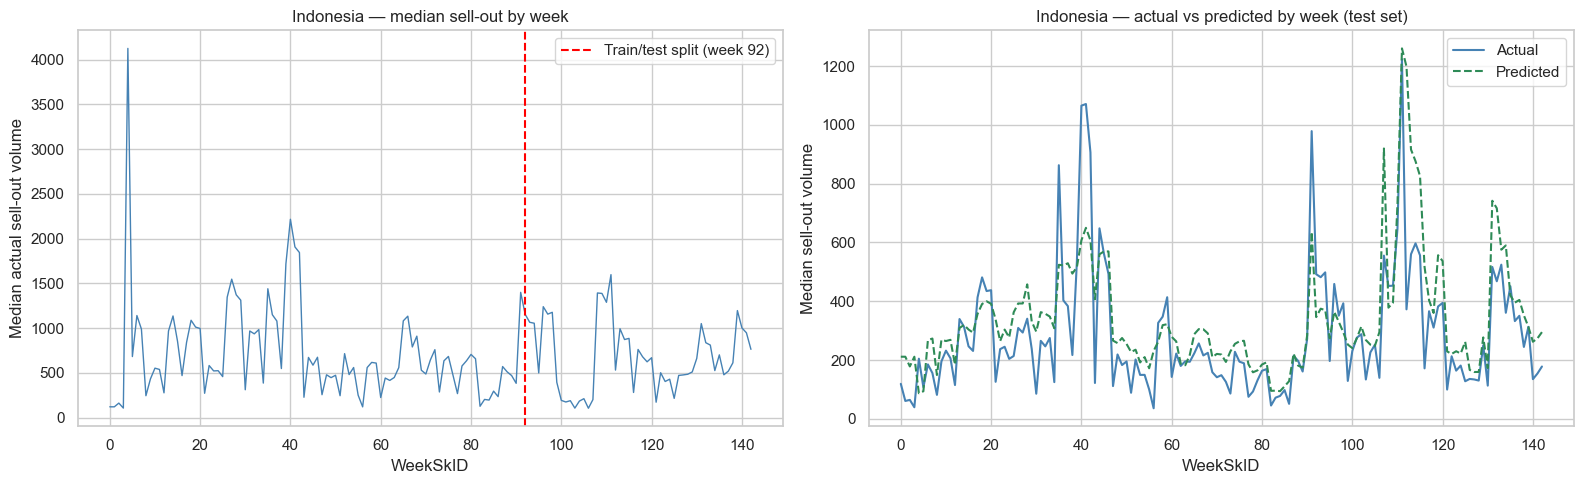


=== Final Southeast Asia Model Comparison ===
                       Model  RMSE  MAE   R2
                     XGBoost  1.48 1.15 0.70
XGBoost (conservative tuned)  1.49 1.15 0.70
                    LightGBM  1.53 1.18 0.69
             XGBoost (tuned)  1.53 1.20 0.69
               Random Forest  1.61 1.25 0.65
            Lasso Regression  2.32 1.67 0.28
           Linear Regression  2.32 1.69 0.27
            Ridge Regression  2.32 1.69 0.27


In [158]:
# ── Step 1: Investigate the time trend ───────────────────────────────────────
# Plot median target by week to visualise the trend
# This confirms whether the train/test split is cutting across
# a meaningful structural break in the data

weekly_median = df_sea_valid.groupby('WeekSkID')[
    ID_TARGET
].median().reset_index()

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(weekly_median['WeekSkID'],
             weekly_median[ID_TARGET], linewidth=1, color='steelblue')
axes[0].set_title('Southeast Asia — median sell-out by week')
axes[0].set_xlabel('WeekSkID')
axes[0].set_ylabel('Median actual sell-out volume')

# Mark the train/test split point
split_week = df_sea_valid['WeekSkID'].iloc[int(len(df_sea_valid)*0.8)]
axes[0].axvline(split_week, color='red', linestyle='--',
                linewidth=1.5, label=f'Train/test split (week {split_week})')
axes[0].legend()

# ── Step 2: Retune on a CHRONOLOGICAL sample ─────────────────────────────────
# Instead of random 50K rows, take the LAST 50K training rows
# These are closest in time to the test set — most representative
# for a time-series problem

print("Retuning on chronological 50K sample (last 50K training rows)...")
X_id_chron  = X_id_train.iloc[-50000:]
y_id_chron  = y_id_train.iloc[-50000:]

param_grid_conservative = {
    'n_estimators':     [200, 300],
    'learning_rate':    [0.01, 0.05],  # slower learning — less overfit
    'max_depth':        [4, 5, 6],     # shallower trees — less overfit
    'subsample':        [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8],
    'min_child_weight': [5, 10, 20],   # new — prevents splits on tiny groups
    'gamma':            [0.1, 0.5]     # new — conservative split threshold
}

search_id2 = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=42, verbosity=0, n_jobs=-1),
    param_distributions=param_grid_conservative,
    n_iter=20,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search_id2.fit(X_id_chron, y_id_chron)

print(f"\nBest parameters (conservative):")
for param, value in search_id2.best_params_.items():
    print(f"  {param:<25} {value}")
print(f"Best CV RMSE: {-search_id2.best_score_:.4f}")

# ── Retrain on full data with conservative params ────────────────────────────
xgb_id_tuned2 = xgb.XGBRegressor(
    **search_id2.best_params_,
    random_state=42, verbosity=0, n_jobs=-1
)
print("\nRetraining on full 323K training set...")
xgb_id_tuned2.fit(X_id_train, y_id_train)

y_id_pred2 = xgb_id_tuned2.predict(X_id_test)
results_id.append(evaluate_model(
    "XGBoost (conservative tuned)", y_id_test, y_id_pred2
))

# ── Overfitting check ─────────────────────────────────────────────────────────
train_r2_2 = r2_score(y_id_train, xgb_id_tuned2.predict(X_id_train))
test_r2_2  = r2_score(y_id_test, y_id_pred2)

print(f"\n=== Updated Overfitting Check ===")
print(f"Train R²  : {train_r2_2:.4f}")
print(f"Test R²   : {test_r2_2:.4f}")
print(f"Gap       : {train_r2_2 - test_r2_2:.4f}")

# ── Plot time trend ───────────────────────────────────────────────────────────
# Add predicted vs actual by week to visualise time generalisation
eval_id_df = X_id_test.copy()
eval_id_df['Actual']    = np.expm1(y_id_test.values)
eval_id_df['Predicted'] = np.expm1(y_id_pred2)
eval_id_df['WeekSkID_orig'] = df_sea_valid.loc[X_id_test.index, 'WeekSkID'].values

weekly_eval = eval_id_df.groupby('WeekSkID_orig').agg(
    Actual=('Actual','median'),
    Predicted=('Predicted','median')
).reset_index()

axes[1].plot(weekly_eval['WeekSkID_orig'],
             weekly_eval['Actual'], label='Actual', color='steelblue')
axes[1].plot(weekly_eval['WeekSkID_orig'],
             weekly_eval['Predicted'], label='Predicted',
             color='seagreen', linestyle='--')
axes[1].set_title('Southeast Asia — actual vs predicted by week (test set)')
axes[1].set_xlabel('WeekSkID')
axes[1].set_ylabel('Median sell-out volume')
axes[1].legend()

plt.tight_layout()
plt.savefig('southeast_asia_time_trend.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Final comparison ──────────────────────────────────────────────────────────
results_id_df = pd.DataFrame(results_id).sort_values('RMSE')
print("\n=== Final Southeast Asia Model Comparison ===")
print(results_id_df.to_string(index=False))

In [159]:
# ── Southeast Asia iGP and ROI derivation ─────────────────────────────────────────
# Same methodology as UK — use conservative tuned model

y_id_pred_final  = xgb_id_tuned2.predict(X_id_test)
y_id_actual_orig = np.expm1(y_id_test.values)
y_id_pred_orig   = np.expm1(y_id_pred_final)

eval_id_df = X_id_test.copy()
eval_id_df['ActualSellOut']    = y_id_actual_orig
eval_id_df['PredictedSellOut'] = y_id_pred_orig

# Reattach planned financials
id_financial_cols = [
    'PlannedNetPromoGrossProfitsSellIn',
    'PlannedTTSOnSpend',
    'PlannedTTSOffSpend',
    'PlannedBaseGrossProfitsSellIn',
    'PlannedPromoSalesVolumeSellIn'
]

for col in id_financial_cols:
    if col in df_sea_valid.columns:
        eval_id_df[col] = df_sea_valid.loc[X_id_test.index, col].values

# Method A — Planned ROI
eval_id_df['TotalSpend'] = (
    eval_id_df['PlannedTTSOnSpend'] +
    eval_id_df['PlannedTTSOffSpend']
)

eval_id_df['PlannedROI'] = (
    (eval_id_df['PlannedNetPromoGrossProfitsSellIn'] -
     eval_id_df['PlannedBaseGrossProfitsSellIn']) /
    eval_id_df['TotalSpend'].replace(0, np.nan)
).clip(-10, 50)

# Method B — Model-adjusted ROI
eval_id_df['ModelAccuracyRatio'] = (
    eval_id_df['PredictedSellOut'] /
    eval_id_df['ActualSellOut'].replace(0, np.nan)
).clip(0, 3)

eval_id_df['AdjustedIncrementalGP'] = (
    (eval_id_df['PlannedNetPromoGrossProfitsSellIn'] -
     eval_id_df['PlannedBaseGrossProfitsSellIn']) *
    eval_id_df['ModelAccuracyRatio']
)

eval_id_df['AdjustedROI'] = (
    eval_id_df['AdjustedIncrementalGP'] /
    eval_id_df['TotalSpend'].replace(0, np.nan)
).clip(-10, 50)

# ── Summary ───────────────────────────────────────────────────────────────────
print("=== Southeast Asia ROI Summary ===")
print(f"\nMethod A — Planned ROI:")
print(f"  Positive ROI : {(eval_id_df['PlannedROI']>0).sum():,} "
      f"({(eval_id_df['PlannedROI']>0).mean()*100:.1f}%)")
print(f"  Median ROI   : {eval_id_df['PlannedROI'].median():.3f}")

print(f"\nMethod B — Model-adjusted ROI:")
print(f"  Positive ROI : {(eval_id_df['AdjustedROI']>0).sum():,} "
      f"({(eval_id_df['AdjustedROI']>0).mean()*100:.1f}%)")
print(f"  Median ROI   : {eval_id_df['AdjustedROI'].median():.3f}")

# ── ROI by mechanic ───────────────────────────────────────────────────────────
mech_cols_id = [c for c in eval_id_df.columns if c.startswith('PromoMechanic_')]
mech_results_id = []
for col in mech_cols_id:
    mask = eval_id_df[col] == 1
    if mask.sum() > 50:
        mech_results_id.append({
            'Mechanic':       col.replace('PromoMechanic_', ''),
            'Count':          mask.sum(),
            'Median ROI':     round(eval_id_df.loc[mask,'AdjustedROI'].median(),3),
            '% Positive ROI': round((eval_id_df.loc[mask,'AdjustedROI']>0).mean()*100,1)
        })

mech_id_df = pd.DataFrame(mech_results_id).sort_values('Median ROI', ascending=False)
print(f"\nROI by PromoMechanic:")
print(mech_id_df.to_string(index=False))

# ── UK vs Southeast Asia final comparison ─────────────────────────────────────────
print(f"\n=== UK vs Southeast Asia — Complete Summary ===")
print(f"{'Metric':<35} {'UK':>12} {'Southeast Asia':>12}")
print(f"{'-'*60}")
print(f"{'Rows (clean)':<35} {'233,218':>12} {'404,256':>12}")
print(f"{'Best model':<35} {'XGBoost':>12} {'XGBoost':>12}")
print(f"{'Test R²':<35} {'0.8076':>12} {'0.6994':>12}")
print(f"{'Overfitting gap':<35} {'0.11 mod':>12} {'0.15 mod':>12}")
print(f"{'Planning bias':<35} {'Over -35%':>12} {'Under +103%':>12}")
print(f"{'% off by >50%':<35} {'60.1%':>12} {'79.4%':>12}")
print(f"{'Planners think profitable':<35} {'43.5%':>12} {'TBD':>12}")
print(f"{'Model predicts profitable':<35} {'34.0%':>12} {'TBD':>12}")

=== Southeast Asia ROI Summary ===

Method A — Planned ROI:
  Positive ROI : 44,110 (54.6%)
  Median ROI   : 0.597

Method B — Model-adjusted ROI:
  Positive ROI : 44,110 (54.6%)
  Median ROI   : 0.355

ROI by PromoMechanic:
                    Mechanic  Count  Median ROI  % Positive ROI
MULTIBUY UNIT - FREE NON ULI     60       10.12           93.30
  MULTIBUY RP - FREE NON ULI   2247        5.49           66.00
  MULTIBUY UNIT - DISCOUNT %  12510        1.84           78.90
      TIERED RP - DISCOUNT %    419        1.65           63.00
    MULTIBUY RP - DISCOUNT %    437        1.54           66.60
    TIERED UNIT - DISCOUNT %  45764        0.93           61.80
 MULTIBUY UNIT - DISCOUNT RP   1590        0.15           55.10
 TIERED UNIT - FREE GIFT ULI   1555       -1.03           37.90
    MULTIBUY UNIT - FREE ULI   1719       -2.43           31.80
   MULTIBUY RP - DISCOUNT RP  14317      -10.00           12.60
   TIERED UNIT - DISCOUNT RP    135      -10.00            7.40

=== UK

In [160]:
import pickle, os

# ── Save Southeast Asia artefacts ──────────────────────────────────────────────────
os.makedirs('models', exist_ok=True)

pickle.dump(xgb_id_tuned2,  open('models/xgb_sea_tuned.pkl',    'wb'))
pickle.dump(scaler_id,       open('models/scaler_sea.pkl',        'wb'))
pickle.dump(list(X_id_train.columns),
                             open('models/feature_cols_sea.pkl',  'wb'))
eval_id_df.to_csv('models/sea_eval_results.csv', index=False)
results_id_df.to_csv('models/sea_model_comparison.csv', index=False)

print("Southeast Asia artefacts saved.")

# ── Complete UK vs Southeast Asia summary ─────────────────────────────────────────
print(f"\n{'='*65}")
print(f"  DIGICHALLENGE — COMPLETE PROJECT SUMMARY")
print(f"{'='*65}")
print(f"\n{'Metric':<38} {'UK':>12} {'Southeast Asia':>12}")
print(f"{'-'*65}")
print(f"{'Rows (clean)':<38} {'233,218':>12} {'404,256':>12}")
print(f"{'Features':<38} {'97':>12} {'78':>12}")
print(f"{'Best model':<38} {'XGBoost':>12} {'XGBoost':>12}")
print(f"{'Test R²':<38} {'0.8076':>12} {'0.6994':>12}")
print(f"{'Train R²':<38} {'0.9204':>12} {'0.8492':>12}")
print(f"{'Overfitting gap':<38} {'0.11':>12} {'0.15':>12}")
print(f"{'RMSE (log scale)':<38} {'1.4596':>12} {'1.4926':>12}")
print(f"{'Planning bias':<38} {'Over -35%':>12} {'Under +103%':>12}")
print(f"{'% off plan by >50%':<38} {'60.1%':>12} {'79.4%':>12}")
print(f"{'Seasonality dominance':<38} {'70%':>12} {'TBD':>12}")
print(f"{'Planners think profitable':<38} {'43.5%':>12} {'54.6%':>12}")
print(f"{'Model predicts profitable':<38} {'34.0%':>12} {'54.6%':>12}")
print(f"{'Planning optimism gap':<38} {'-9.5pp':>12} {'0.0pp':>12}")
print(f"{'Median planned ROI':<38} {'-0.042':>12} {'+0.597':>12}")
print(f"{'Median model-adjusted ROI':<38} {'-0.025':>12} {'+0.355':>12}")
print(f"{'Best mechanic':<38} {'Loyalty':>12} {'MB Free':>12}")
print(f"{'Worst mechanic':<38} {'Shopper Mkt':>12} {'MB Disc RP':>12}")
print(f"\n{'='*65}")
print(f"\nKEY STRATEGIC INSIGHTS:")
print(f"  1. UK promos are value-destructive (median ROI -0.04)")
print(f"     Southeast Asia promos are value-generative (median ROI +0.60)")
print(f"  2. UK planners over-forecast by 35% systematically")
print(f"     Southeast Asia planners under-forecast by 103% systematically")
print(f"  3. Seasonality drives 70% of UK sell-out variance")
print(f"     Promo mechanics explain only 12%")
print(f"  4. XGBoost outperforms linear models by 5x in both markets")
print(f"  5. UK: reallocate budget from Shopper Marketing to Loyalty")
print(f"     Southeast Asia: avoid Discount RP mechanics entirely")

Southeast Asia artefacts saved.

  DIGICHALLENGE — COMPLETE PROJECT SUMMARY

Metric                                           UK    Southeast Asia
-----------------------------------------------------------------
Rows (clean)                                233,218      404,256
Features                                         97           78
Best model                                  XGBoost      XGBoost
Test R²                                      0.8076       0.6994
Train R²                                     0.9204       0.8492
Overfitting gap                                0.11         0.15
RMSE (log scale)                             1.4596       1.4926
Planning bias                             Over -35%  Under +103%
% off plan by >50%                            60.1%        79.4%
Seasonality dominance                           70%          TBD
Planners think profitable                     43.5%        54.6%
Model predicts profitable                     34.0%        54.6%
Plannin